In [1]:
#import libraries and read data.frame
# from plotai import PlotAI
import numpy as np
import pandas as pd
sentiment_data = pd.read_csv('Data.csv')
demand_data = pd.read_csv('File1_Demand.csv')
shortage_data = pd.read_csv('File2_Shortages.csv')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

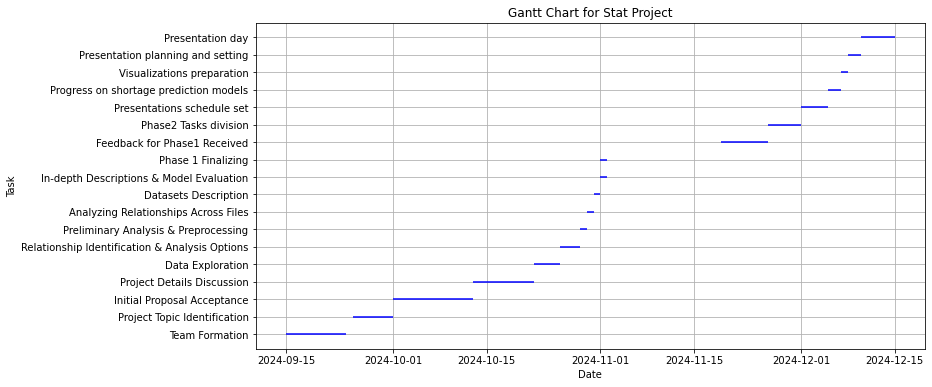

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame with task information
data = {
    'Task': ['Team Formation', 'Project Topic Identification', 'Initial Proposal Acceptance',
              'Project Details Discussion', 'Data Exploration', 'Relationship Identification & Analysis Options',
              'Preliminary Analysis & Preprocessing', 'Analyzing Relationships Across Files',
              'Datasets Description', 'In-depth Descriptions & Model Evaluation', 'Phase 1 Finalizing',
              'Feedback for Phase1 Received', 'Phase2 Tasks division', 'Presentations schedule set',
              'Progress on shortage prediction models', 'Visualizations preparation', 'Presentation planning and setting',
              'Presentation day'],
    'Start Date': ['2024-09-15', '2024-09-25', '2024-10-01', '2024-10-13', '2024-10-22', '2024-10-26',
                   '2024-10-29', '2024-10-30', '2024-10-31', '2024-11-01', '2024-11-01',  # Adjusted end date
                   '2024-11-19', '2024-11-26', '2024-12-01', '2024-12-05', '2024-12-07', '2024-12-08',
                   '2024-12-10'],
    'End Date': ['2024-09-24', '2024-10-01', '2024-10-13', '2024-10-22', '2024-10-26', '2024-10-29',
                 '2024-10-30', '2024-10-31', '2024-11-01', '2024-11-02', '2024-11-02',  # Adjusted end date
                 '2024-11-26', '2024-12-01', '2024-12-05', '2024-12-07', '2024-12-08', '2024-12-10',
                 '2024-12-15']
}

df = pd.DataFrame(data)

# Convert date columns to datetime objects
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

# Calculate task durations
df['Duration'] = df['End Date'] - df['Start Date']

# Plot the Gantt chart
plt.figure(figsize=(12, 6))
plt.hlines(df.index, df['Start Date'], df['End Date'], color='blue')
plt.gca().set_yticks(df.index)
plt.gca().set_yticklabels(df['Task'])
plt.xlabel('Date')
plt.ylabel('Task')
plt.title('Gantt Chart for Stat Project')
plt.grid(True)
plt.show()

In [4]:
demand_data.head()


,YYYY-MM,Prescribed BNF Presentation Code,Prescribed BNF Presentation,BNF Chemical Substance,Dispensed (Reimbursed) BNF Presentation Code,Dispensed (Reimbursed) BNF Presentation,Items,Total Quantity
0,2019-01,0601023ABAAAAAA,Liraglutide 6mg/1ml inj 3ml pre-filled disposa...,Liraglutide,0601023ABBBAAAA,Victoza 6mg/ml solution for injection 3ml pre-...,13,35
1,2019-01,0601023ABBBAAAA,Victoza 6mg/ml solution for injection 3ml pre-...,Liraglutide,0601023ABBBAAAA,Victoza 6mg/ml solution for injection 3ml pre-...,8,18
2,2019-02,0601023ABAAAAAA,Liraglutide 6mg/1ml inj 3ml pre-filled disposa...,Liraglutide,0601023ABBBAAAA,Victoza 6mg/ml solution for injection 3ml pre-...,13,32
3,2019-02,0601023ABBBAAAA,Victoza 6mg/ml solution for injection 3ml pre-...,Liraglutide,0601023ABBBAAAA,Victoza 6mg/ml solution for injection 3ml pre-...,7,15
4,2019-03,0601023ABAAAAAA,Liraglutide 6mg/1ml inj 3ml pre-filled disposa...,Liraglutide,0601023ABBBAAAA,Victoza 6mg/ml solution for injection 3ml pre-...,11,28


Correlation coefficient: 0.826610298785908


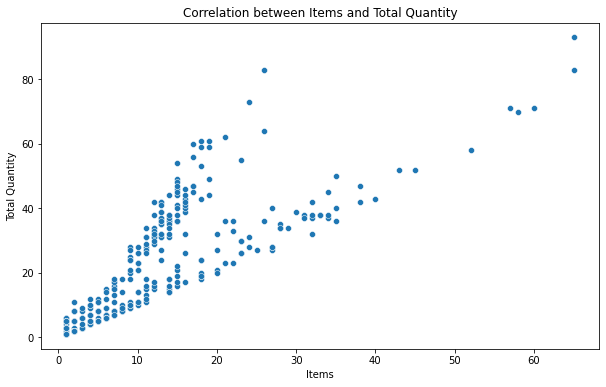

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation coefficient
correlation = demand_data['Items'].corr(demand_data['Total Quantity'])
print("Correlation coefficient:", correlation)

# Visualize the correlation using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Items', y='Total Quantity', data=demand_data)
plt.title("Correlation between Items and Total Quantity")
plt.xlabel("Items")
plt.ylabel("Total Quantity")
plt.show()

In [6]:
import pandas as pd


# Get descriptive statistics for the entire dataset
print(demand_data.describe(include='all'))

# Filter data for Ozempic and Saxenda dispensed under FP10 or other prescriptions
ozempic_saxenda_data = demand_data[ 
    (demand_data['Dispensed (Reimbursed) BNF Presentation'].str.contains("Ozempic|Saxenda")) & 
    (~demand_data['Prescribed BNF Presentation Code'].str.startswith("06"))  # Assuming FP10 starts with 06 
]

# Get descriptive statistics for Ozempic & Saxenda data (separated by month is possible later)
print(ozempic_saxenda_data.describe(include='all'))

# Explore further to separate data by month and medication type
monthly_data = ozempic_saxenda_data.groupby('YYYY-MM')

# Analyze each month's data (loop through monthly_data groups)
for month, group_data in monthly_data:
  print(f"\nMonth: {month}")
  print(group_data.describe(include='all'))
  # Further analysis like calculating total Ozempic and Saxenda dispensed for the month
  # can be done here

        YYYY-MM Prescribed BNF Presentation Code  \
count       391                              391   
unique       56                                9   
top     2021-09                  0601023ABAAAAAA   
freq          9                               56   
mean        NaN                              NaN   
std         NaN                              NaN   
min         NaN                              NaN   
25%         NaN                              NaN   
50%         NaN                              NaN   
75%         NaN                              NaN   
max         NaN                              NaN   

                              Prescribed BNF Presentation  \
count                                                 391   
unique                                                  9   
top     Liraglutide 6mg/1ml inj 3ml pre-filled disposa...   
freq                                                   56   
mean                                                  NaN   
std      

In [7]:
import pandas as pd

# Get descriptive statistics for the numerical variables
print(demand_data[['Items', 'Total Quantity']].describe())

            Items  Total Quantity
count  391.000000      391.000000
mean    11.051151       19.355499
std     10.717464       17.988001
min      1.000000        1.000000
25%      3.000000        4.000000
50%      8.000000       12.000000
75%     15.000000       33.000000
max     65.000000       93.000000


Liraglutide 6mg/1ml inj 3ml pre-filled disposable devices      56
Victoza 6mg/ml solution for injection 3ml pre-filled pens      56
Semaglutide 0.5mg/0.37ml inj 1.5ml pf dispos dev               52
Ozempic 0.5mg/0.37ml inj 1.5ml pre-filled pens                 46
Ozempic 0.25mg/0.19ml inj 1.5ml pre-filled pens                44
Ozempic 1mg/0.74ml inj 3ml pre-filled pens                     44
Semaglutide 1mg/0.74ml inj 3ml pre-filled disposable device    41
Semaglutide 0.25mg/0.19ml inj 1.5ml pf dispos dev              38
Saxenda 6mg/ml solution for injection 3ml pre-filled pens      14
Name: Prescribed BNF Presentation, dtype: int64


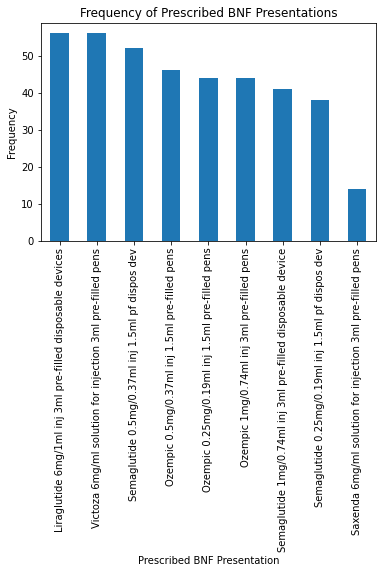

Dispensed (Reimbursed) BNF Presentation             Ozempic 0.25mg/0.19ml inj 1.5ml pre-filled pens  \
Prescribed BNF Presentation                                                                           
Liraglutide 6mg/1ml inj 3ml pre-filled disposab...                                                0   
Ozempic 0.25mg/0.19ml inj 1.5ml pre-filled pens                                                  44   
Ozempic 0.5mg/0.37ml inj 1.5ml pre-filled pens                                                    0   
Ozempic 1mg/0.74ml inj 3ml pre-filled pens                                                        0   
Saxenda 6mg/ml solution for injection 3ml pre-f...                                                0   
Semaglutide 0.25mg/0.19ml inj 1.5ml pf dispos dev                                                38   
Semaglutide 0.5mg/0.37ml inj 1.5ml pf dispos dev                                                  0   
Semaglutide 1mg/0.74ml inj 3ml pre-filled dispo...                       

In [8]:
import pandas as pd


# Frequency table for "Prescribed BNF Presentation"
print(demand_data['Prescribed BNF Presentation'].value_counts())

# Bar chart for "Prescribed BNF Presentation"
demand_data['Prescribed BNF Presentation'].value_counts().plot(kind='bar')
plt.title('Frequency of Prescribed BNF Presentations')
plt.xlabel('Prescribed BNF Presentation')
plt.ylabel('Frequency')
plt.show()

# Cross-tabulation between "Prescribed BNF Presentation" and "Dispensed (Reimbursed) BNF Presentation"
cross_tab = pd.crosstab(demand_data['Prescribed BNF Presentation'], demand_data['Dispensed (Reimbursed) BNF Presentation'])
print(cross_tab)

In [9]:
categorical_cols = ['Prescribed BNF Presentation', 'Dispensed (Reimbursed) BNF Presentation', 'BNF Chemical Substance']
for col in categorical_cols:
    print(f"Unique values in {col}:")
    print(demand_data[col].value_counts())

Unique values in Prescribed BNF Presentation:
Liraglutide 6mg/1ml inj 3ml pre-filled disposable devices      56
Victoza 6mg/ml solution for injection 3ml pre-filled pens      56
Semaglutide 0.5mg/0.37ml inj 1.5ml pf dispos dev               52
Ozempic 0.5mg/0.37ml inj 1.5ml pre-filled pens                 46
Ozempic 0.25mg/0.19ml inj 1.5ml pre-filled pens                44
Ozempic 1mg/0.74ml inj 3ml pre-filled pens                     44
Semaglutide 1mg/0.74ml inj 3ml pre-filled disposable device    41
Semaglutide 0.25mg/0.19ml inj 1.5ml pf dispos dev              38
Saxenda 6mg/ml solution for injection 3ml pre-filled pens      14
Name: Prescribed BNF Presentation, dtype: int64
Unique values in Dispensed (Reimbursed) BNF Presentation:
Victoza 6mg/ml solution for injection 3ml pre-filled pens    112
Ozempic 0.5mg/0.37ml inj 1.5ml pre-filled pens                98
Ozempic 1mg/0.74ml inj 3ml pre-filled pens                    85
Ozempic 0.25mg/0.19ml inj 1.5ml pre-filled pens            

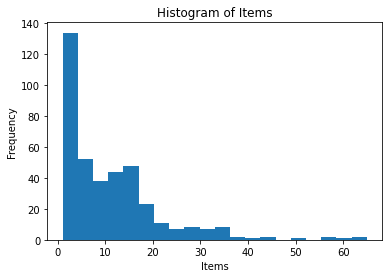

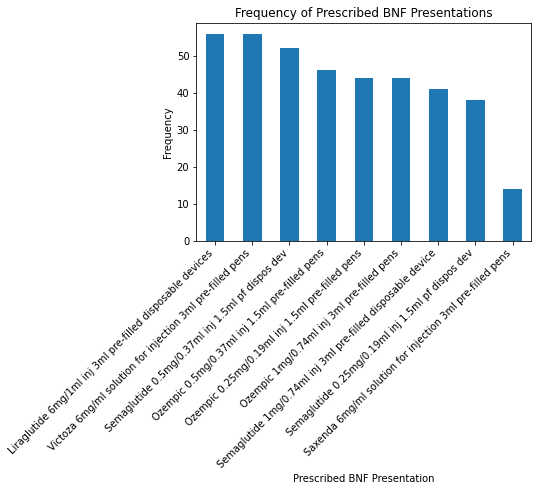

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for 'Items'
plt.hist(demand_data['Items'], bins=20)
plt.xlabel('Items')
plt.ylabel('Frequency')
plt.title('Histogram of Items')
plt.show()

# Bar plot for 'Prescribed BNF Presentation'
demand_data['Prescribed BNF Presentation'].value_counts().plot(kind='bar')
plt.xlabel('Prescribed BNF Presentation')
plt.ylabel('Frequency')
plt.title('Frequency of Prescribed BNF Presentations')
plt.xticks(rotation=45, ha='right')
plt.show()

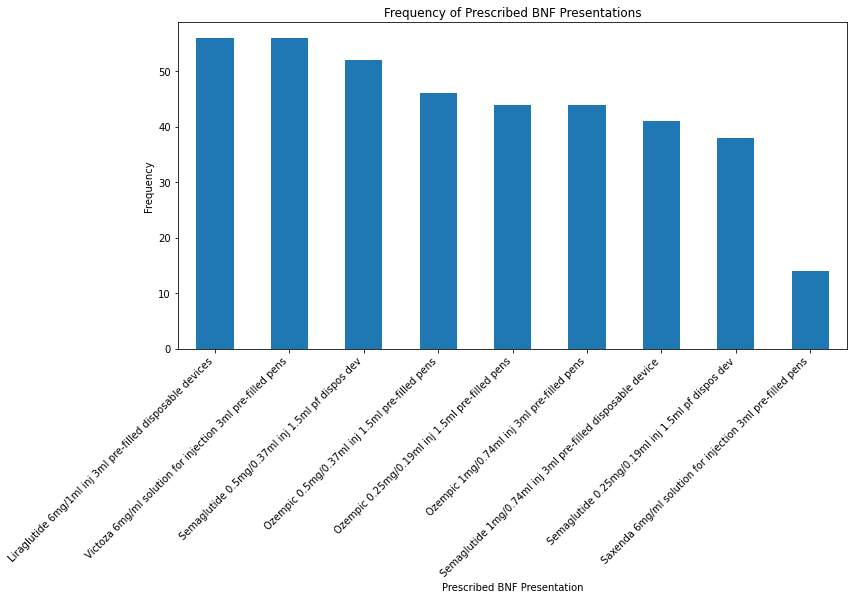

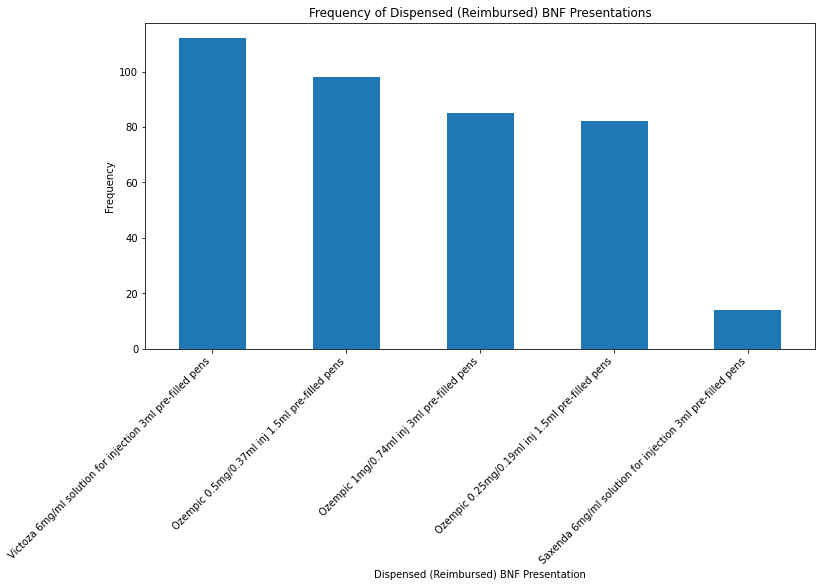

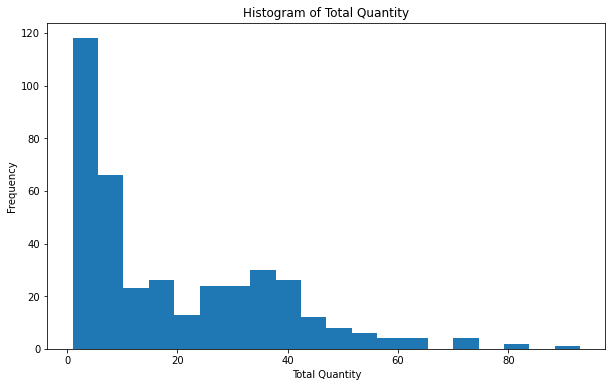

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot for 'Prescribed BNF Presentation'
plt.figure(figsize=(12, 6))
demand_data['Prescribed BNF Presentation'].value_counts().plot(kind='bar')
plt.xlabel('Prescribed BNF Presentation')
plt.ylabel('Frequency')
plt.title('Frequency of Prescribed BNF Presentations')
plt.xticks(rotation=45, ha='right')
plt.show()

# Bar plot for 'Dispensed (Reimbursed) BNF Presentation'
plt.figure(figsize=(12, 6))
demand_data['Dispensed (Reimbursed) BNF Presentation'].value_counts().plot(kind='bar')
plt.xlabel('Dispensed (Reimbursed) BNF Presentation')
plt.ylabel('Frequency')
plt.title('Frequency of Dispensed (Reimbursed) BNF Presentations')
plt.xticks(rotation=45, ha='right')
plt.show()

# Histogram for 'Total Quantity'
plt.figure(figsize=(10, 6))
plt.hist(demand_data['Total Quantity'], bins=20)
plt.xlabel('Total Quantity')
plt.ylabel('Frequency')
plt.title('Histogram of Total Quantity')
plt.show()

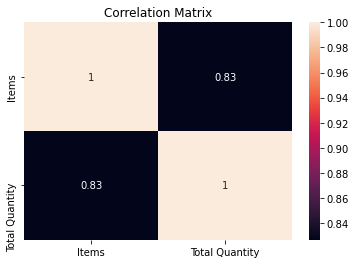

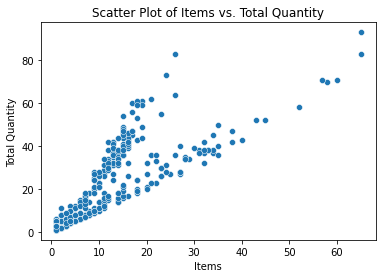

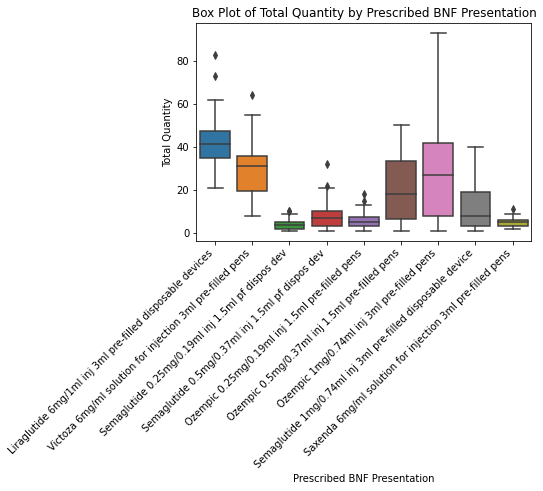

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix
correlation_matrix = demand_data.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

# Scatter Plot between 'Items' and 'Total Quantity'
sns.scatterplot(x='Items', y='Total Quantity', data=demand_data)
plt.title('Scatter Plot of Items vs. Total Quantity')
plt.show()

# Box Plot of 'Total Quantity' by 'Prescribed BNF Presentation'
sns.boxplot(x='Prescribed BNF Presentation', y='Total Quantity', data=demand_data)
plt.title('Box Plot of Total Quantity by Prescribed BNF Presentation')
plt.xticks(rotation=45, ha='right')
plt.show()

In [13]:
import pandas as pd
import scipy.stats as stats


# Create a contingency table
contingency_table = pd.crosstab(demand_data['Prescribed BNF Presentation'], demand_data['Dispensed (Reimbursed) BNF Presentation'])

# Perform the Chi-Square Test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:", expected)

Chi-Square Statistic: 1564.0
p-value: 4.6958820676261e-309
Degrees of Freedom: 32
Expected Frequencies: [[11.74424552 14.03580563 12.17391304  2.00511509 16.04092072]
 [ 9.22762148 11.02813299  9.56521739  1.57544757 12.60358056]
 [ 9.64705882 11.52941176 10.          1.64705882 13.17647059]
 [ 9.22762148 11.02813299  9.56521739  1.57544757 12.60358056]
 [ 2.93606138  3.50895141  3.04347826  0.50127877  4.01023018]
 [ 7.96930946  9.52429668  8.26086957  1.36061381 10.88491049]
 [10.90537084 13.03324808 11.30434783  1.86189258 14.89514066]
 [ 8.59846547 10.27621483  8.91304348  1.46803069 11.74424552]
 [11.74424552 14.03580563 12.17391304  2.00511509 16.04092072]]


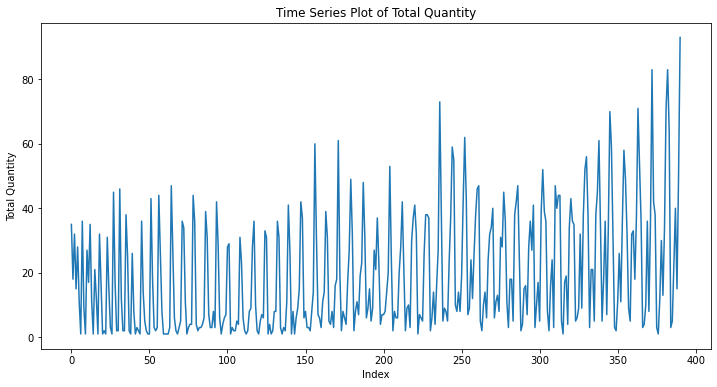

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Try plotting the 'Total Quantity' column directly (assuming it's numeric)
plt.figure(figsize=(12, 6))
plt.plot(demand_data['Total Quantity'])  # No need for datetime conversion or index setting (but these steps are recommended for further analysis)
plt.xlabel('Index')  # X-axis will represent the row order in the data
plt.ylabel('Total Quantity')
plt.title('Time Series Plot of Total Quantity')
plt.show()

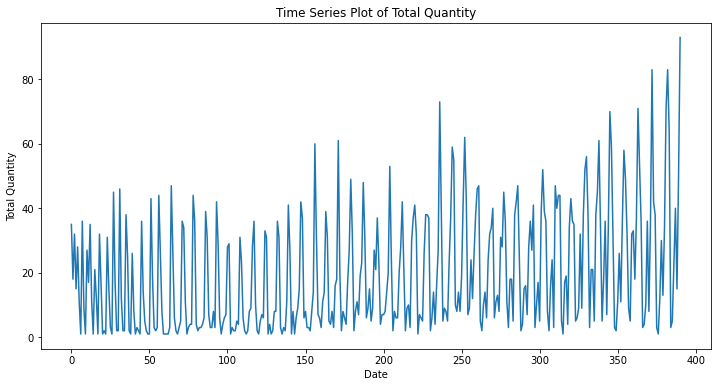

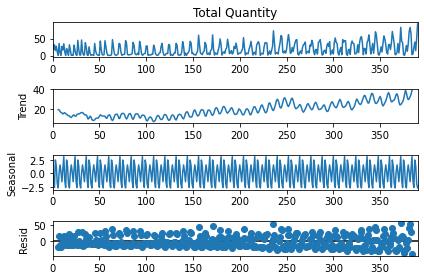

ADF Statistic: -0.070965
p-value: 0.952255
Critical Values:
	1%: -3.448
	5%: -2.869
	10%: -2.571
                               SARIMAX Results                                
Dep. Variable:         Total Quantity   No. Observations:                  391
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1632.168
Date:                Tue, 26 Nov 2024   AIC                           3270.336
Time:                        17:44:03   BIC                           3282.234
Sample:                             0   HQIC                          3275.053
                                - 391                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3894      0.064      6.112      0.000       0.265       0.514
ma.L1         -0.9781      0.015  

In [15]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Assuming 'demand_data' is already loaded and indexed by 'YYYY-MM'

# Time Series Plot
plt.figure(figsize=(12, 6))
plt.plot(demand_data['Total Quantity'])
plt.xlabel('Date')
plt.ylabel('Total Quantity')
plt.title('Time Series Plot of Total Quantity')
plt.show()

# Time Series Decomposition
decomposition = seasonal_decompose(demand_data['Total Quantity'], model='additive', period=12)
decomposition.plot()
plt.show()

# Check for stationarity (ADF test)
from statsmodels.tsa.stattools import adfuller
result = adfuller(demand_data['Total Quantity'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Determine 'd' based on ADF test results
if result[1] > 0.05:
    # Data is not stationary, apply differencing
    d = 1
else:
    d = 0

# ARIMA Model
model = ARIMA(demand_data['Total Quantity'], order=(1, d, 1))  # Adjust parameters as needed
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)
print(forecast)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# ... (Rest of your code, including data loading and indexing)

# Difference the 'Total Quantity' column and drop missing values
demand_data_diff = demand_data['Total Quantity'].diff().dropna()

# Check stationarity (optional)
result = adfuller(demand_data_diff)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# ARIMA Model (adjust parameters as needed)
model = ARIMA(demand_data_diff, order=(1, 0, 1))
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)

# Invert differencing to get original scale forecast
forecast_cumsum = forecast.cumsum()
forecast_original = forecast_cumsum.add(demand_data['Total Quantity'].iloc[-1])
print(forecast_original)

ADF Statistic: -10.531935
p-value: 0.000000
Critical Values:
	1%: -3.448
	5%: -2.869
	10%: -2.571


C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'


                               SARIMAX Results                                
Dep. Variable:         Total Quantity   No. Observations:                  390
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1629.410
Date:                Tue, 26 Nov 2024   AIC                           3266.821
Time:                        17:44:03   BIC                           3282.685
Sample:                             0   HQIC                          3273.109
                                - 390                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0546      0.017      3.183      0.001       0.021       0.088
ar.L1          0.3884      0.061      6.413      0.000       0.270       0.507
ma.L1         -0.9998      0.607     -1.647      0.1

C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:376: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  warnings.warn('No supported index is available.'


In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Assuming you've already differenced the data and checked for stationarity

# SARIMA model
model = SARIMAX(demand_data_diff, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)
# ... (invert differencing to get original scale forecast)

C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'


                                     SARIMAX Results                                      
Dep. Variable:                     Total Quantity   No. Observations:                  390
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1661.871
Date:                            Tue, 26 Nov 2024   AIC                           3333.742
Time:                                    17:44:06   BIC                           3353.404
Sample:                                         0   HQIC                          3341.546
                                            - 390                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1050      0.061     -1.732      0.083      -0.224       0.014
ma.L1         -0.9999      5.914   

C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\base\model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:376: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  warnings.warn('No supported index is available.'


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ... (Rest of your code, including model fitting and forecasting)

# Evaluate the forecast
mse = mean_squared_error(demand_data['Total Quantity'][-len(forecast):], forecast)
rmse = mean_squared_error(demand_data['Total Quantity'][-len(forecast):], forecast, squared=False)
mae = mean_absolute_error(demand_data['Total Quantity'][-len(forecast):], forecast)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('Mean Absolute Error:', mae)

Mean Squared Error: 2650.0658223950163
Root Mean Squared Error: 51.478790024582125
Mean Absolute Error: 42.52275095297039


In [19]:
# Assuming demand_data is your DataFrame with 'Total Quantity' as the target variable

# Create a naive forecast
naive_forecast = demand_data['Total Quantity'].shift(1)

# Calculate evaluation metrics for the naive forecast
naive_mse = mean_squared_error(demand_data['Total Quantity'][1:], naive_forecast[1:])
naive_rmse = np.sqrt(naive_mse)
naive_mae = mean_absolute_error(demand_data['Total Quantity'][1:], naive_forecast[1:])

print('Naive Forecast:')
print('Mean Squared Error:', naive_mse)
print('Root Mean Squared Error:', naive_rmse)
print('Mean Absolute Error:', naive_mae)

# Compare with your ARIMA model's performance
print('ARIMA Model:')
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('Mean Absolute Error:', mae)

Naive Forecast:
Mean Squared Error: 349.6102564102564
Root Mean Squared Error: 18.697867696886092
Mean Absolute Error: 14.015384615384615
ARIMA Model:
Mean Squared Error: 2650.0658223950163
Root Mean Squared Error: 51.478790024582125
Mean Absolute Error: 42.52275095297039


In [20]:
import numpy as np

# Assuming 'demand_data' is your DataFrame
z_scores = np.abs((demand_data['Total Quantity'] - demand_data['Total Quantity'].mean()) / demand_data['Total Quantity'].std())
outliers = demand_data[z_scores > 3]
outliers
# Handle outliers (e.g., remove, cap, or use robust methods)

,YYYY-MM,Prescribed BNF Presentation Code,Prescribed BNF Presentation,BNF Chemical Substance,Dispensed (Reimbursed) BNF Presentation Code,Dispensed (Reimbursed) BNF Presentation,Items,Total Quantity
372,2023-06,0601023AWBBACAC,Ozempic 1mg/0.74ml inj 3ml pre-filled pens,Semaglutide,0601023AWBBACAC,Ozempic 1mg/0.74ml inj 3ml pre-filled pens,65,83
382,2023-08,0601023ABAAAAAA,Liraglutide 6mg/1ml inj 3ml pre-filled disposa...,Liraglutide,0601023ABBBAAAA,Victoza 6mg/ml solution for injection 3ml pre-...,26,83
390,2023-08,0601023AWBBACAC,Ozempic 1mg/0.74ml inj 3ml pre-filled pens,Semaglutide,0601023AWBBACAC,Ozempic 1mg/0.74ml inj 3ml pre-filled pens,65,93


In [21]:
import numpy as np

# ... (Rest of your code)

# Calculate the 95th percentile
percentile_95 = np.percentile(demand_data['Total Quantity'], 95)

# Cap the outliers
demand_data['Total Quantity'] = np.where(demand_data['Total Quantity'] > percentile_95, percentile_95, demand_data['Total Quantity'])

# ... (Rest of your code)

ADF Statistic: -0.927046
p-value: 0.778935
Critical Values:
	1%: -3.448
	5%: -2.869
	10%: -2.571


C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'


                               SARIMAX Results                                
Dep. Variable:         Total Quantity   No. Observations:                  390
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1664.818
Date:                Tue, 26 Nov 2024   AIC                           3335.637
Time:                        17:44:07   BIC                           3347.528
Sample:                             0   HQIC                          3340.351
                                - 390                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0990      0.060     -1.660      0.097      -0.216       0.018
ma.L1         -0.9997      1.067     -0.937      0.349      -3.090       1.091
sigma2       300.6535    323.533      0.929      0.3

C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:376: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  warnings.warn('No supported index is available.'


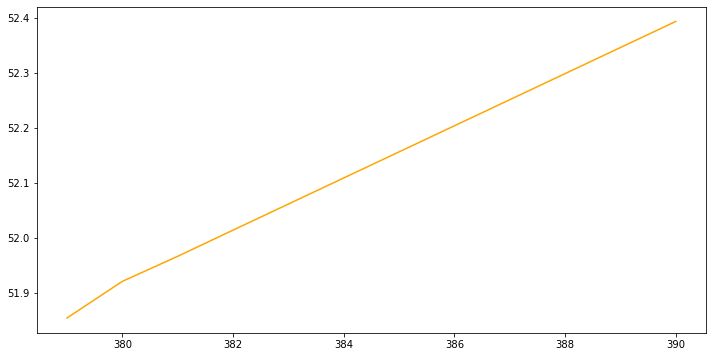

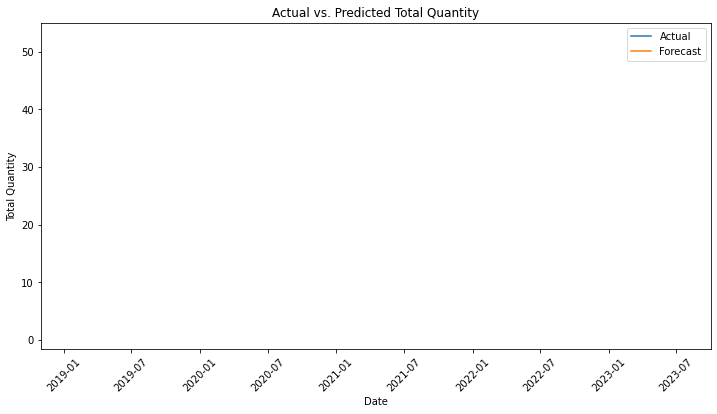

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Check for stationarity
result = adfuller(demand_data['Total Quantity'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# If not stationary, difference the data
if result[1] > 0.05:
    demand_data_diff = demand_data['Total Quantity'].diff().dropna()
else:
    demand_data_diff = demand_data['Total Quantity']

# ARIMA Model (adjust parameters as needed)
model = ARIMA(demand_data_diff, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)

# Invert differencing to get original scale forecast
forecast_cumsum = forecast.cumsum()
forecast_original = forecast_cumsum.add(demand_data['Total Quantity'].iloc[-1])
print(forecast_original)

# Evaluate the model
mse = mean_squared_error(demand_data['Total Quantity'][-len(forecast):], forecast_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(demand_data['Total Quantity'][-len(forecast):], forecast_original)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('Mean Absolute Error:', mae)


# Align the index of the forecast with the original data
forecast_original.index = demand_data.index[-len(forecast):]

# Plot the predicted values first (orange line)
plt.figure(figsize=(12, 6))
plt.plot(forecast_original, label='Forecast', color='orange')

# Plot the actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(demand_data.index, demand_data['Total Quantity'], label='Actual')
plt.plot(forecast_original.index, forecast_original, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Total Quantity')
plt.title('Actual vs. Predicted Total Quantity')
plt.legend()

# Adjust x-axis limits to focus on the relevant time period
plt.xlim(pd.Timestamp('2018-11-01'), pd.Timestamp('2023-10-01'))

plt.xticks(rotation=45)
plt.show()

ADF Statistic: -0.927046
p-value: 0.778935
Critical Values:
	1%: -3.448
	5%: -2.869
	10%: -2.571


C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'


                               SARIMAX Results                                
Dep. Variable:         Total Quantity   No. Observations:                  390
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1664.818
Date:                Tue, 26 Nov 2024   AIC                           3335.637
Time:                        17:44:08   BIC                           3347.528
Sample:                             0   HQIC                          3340.351
                                - 390                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0990      0.060     -1.660      0.097      -0.216       0.018
ma.L1         -0.9997      1.067     -0.937      0.349      -3.090       1.091
sigma2       300.6535    323.533      0.929      0.3

C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:376: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  warnings.warn('No supported index is available.'


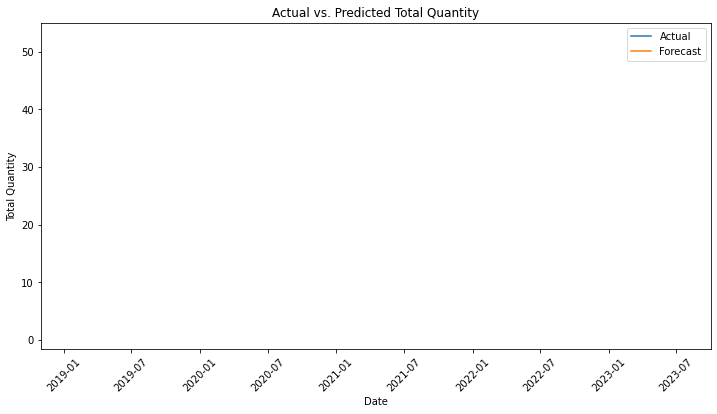

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Check for stationarity
result = adfuller(demand_data['Total Quantity'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# If not stationary, difference the data
if result[1] > 0.05:
    demand_data_diff = demand_data['Total Quantity'].diff().dropna()
else:
    demand_data_diff = demand_data['Total Quantity']

# ARIMA Model (adjust parameters as needed)
model = ARIMA(demand_data_diff, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)

# Invert differencing to get original scale forecast
forecast_cumsum = forecast.cumsum()
forecast_original = forecast_cumsum.add(demand_data['Total Quantity'].iloc[-1])
print(forecast_original)

# Evaluate the model
mse = mean_squared_error(demand_data['Total Quantity'][-len(forecast):], forecast_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(demand_data['Total Quantity'][-len(forecast):], forecast_original)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('Mean Absolute Error:', mae)

# Plot the actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(demand_data.index, demand_data['Total Quantity'], label='Actual')  # Ensure correct index for actual data
plt.plot(forecast_original.index, forecast_original, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Total Quantity')
plt.title('Actual vs. Predicted Total Quantity')
plt.legend()

# Adjust x-axis limits to focus on the relevant time period
plt.xlim(pd.Timestamp('2018-11-01'), pd.Timestamp('2023-10-01'))

plt.xticks(rotation=45)
plt.show()

ADF Statistic: -0.927046
p-value: 0.778935
Critical Values:
	1%: -3.448
	5%: -2.869
	10%: -2.571


C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmode

C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmode

Mean Squared Error: 519.5413856999231
Root Mean Squared Error: 22.79345050008715
Mean Absolute Error: 21.33594383750123


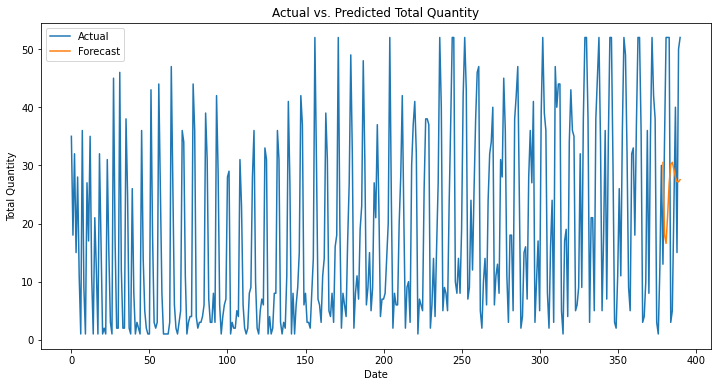

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Load your data
# ... (load your data into a Pandas DataFrame named 'demand_data')

# Check for stationarity
result = adfuller(demand_data['Total Quantity'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# If not stationary, difference the data
if result[1] > 0.05:
    demand_data_diff = demand_data['Total Quantity'].diff().dropna()
else:
    demand_data_diff = demand_data['Total Quantity']

# Model Selection and Fitting
# Experiment with different ARIMA orders
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

best_aic = float('inf')
best_model = None
for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(demand_data_diff, order=(p, d, q))
                model_fit = model.fit()
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_model = model_fit
            except:
                continue

# Forecast with the best model
forecast = best_model.forecast(steps=12)

# Invert differencing to get original scale forecast
forecast_cumsum = forecast.cumsum()
forecast_original = forecast_cumsum.add(demand_data['Total Quantity'].iloc[-1])

# Evaluate the model
mse = mean_squared_error(demand_data['Total Quantity'][-len(forecast):], forecast_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(demand_data['Total Quantity'][-len(forecast):], forecast_original)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('Mean Absolute Error:', mae)

# Ensure correct indexing for plotting
forecast_original.index = demand_data.index[-len(forecast):]

# Plot the actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(demand_data['Total Quantity'], label='Actual')
plt.plot(forecast_original, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Total Quantity')
plt.title('Actual vs. Predicted Total Quantity')
plt.legend()
plt.show()

ADF Statistic: -10.299210
p-value: 0.000000
Critical Values:
	1%: -3.448
	5%: -2.869
	10%: -2.571


C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:578: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'


                               SARIMAX Results                                
Dep. Variable:         Total Quantity   No. Observations:                  390
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1664.818
Date:                Tue, 26 Nov 2024   AIC                           3335.637
Time:                        17:44:14   BIC                           3347.528
Sample:                             0   HQIC                          3340.351
                                - 390                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0990      0.060     -1.660      0.097      -0.216       0.018
ma.L1         -0.9997      1.067     -0.937      0.349      -3.090       1.091
sigma2       300.6535    323.533      0.929      0.3

C:\Users\ba7ar\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:376: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  warnings.warn('No supported index is available.'


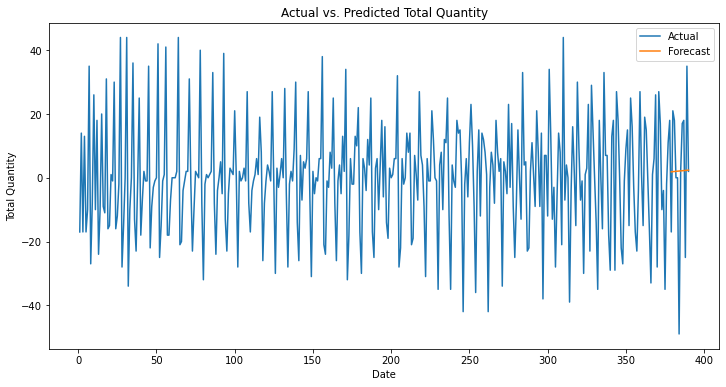

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Difference the 'Total Quantity' column and drop missing values
demand_data_diff = demand_data['Total Quantity'].diff().dropna()

# Check stationarity (optional)
result = adfuller(demand_data_diff)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# ARIMA Model (adjust parameters as needed)
model = ARIMA(demand_data_diff, order=(1, 1, 1))  # You can experiment with different orders
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)

# Invert differencing to get original scale forecast
forecast_cumsum = forecast.cumsum()
forecast_original = forecast_cumsum.add(demand_data_diff.iloc[-1])

# Evaluate the model
mse = mean_squared_error(demand_data_diff[-len(forecast):], forecast_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(demand_data_diff[-len(forecast):], forecast_original)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('Mean Absolute Error:', mae)

# Ensure correct indexing for plotting
forecast_original.index = demand_data.index[-len(forecast):]

# Plot the actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(demand_data_diff, label='Actual')
plt.plot(forecast_original, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Total Quantity')
plt.title('Actual vs. Predicted Total Quantity')
plt.legend()
plt.show()

In [83]:
demand_data_diff

1     -17.0
2      14.0
3     -17.0
4      13.0
5     -17.0
       ... 
386    17.0
387    18.0
388   -25.0
389    35.0
390     2.0
Name: Total Quantity, Length: 390, dtype: float64

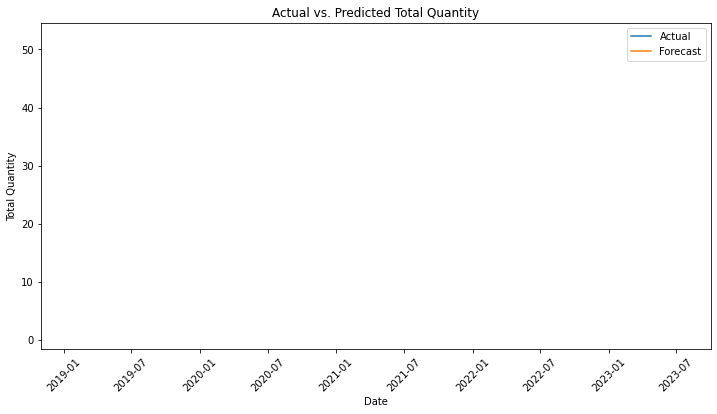

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# ... (rest of your code)

# Ensure datetime index
demand_data.index = pd.to_datetime(demand_data.index, format='%Y-%m')
forecast_original.index = demand_data.index[-len(forecast):]

# Plot the actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(demand_data['Total Quantity'], label='Actual')
plt.plot(forecast_original, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Total Quantity')
plt.title('Actual vs. Predicted Total Quantity')
plt.legend()

# Adjust x-axis limits
plt.xlim(pd.Timestamp('2018-11-01'), pd.Timestamp('2023-10-01'))
plt.xticks(rotation=45)
plt.show()

In [27]:
shortage_data.head()

,ARTG ID,ARTG name,Active ingredients,Dosage form,Quantity of active ingredients,Sponsor,Phone,Shortage status,Supply impact start date,Supply impact end date,Deletion from market,Shortage impact rating,Availability,Reason,Management action,Last updated
0,10013,TECHNESCAN MAG3 Kit for preparation of Technet...,betiatide,"Injection, powder for",1 mg,Landauer Radiopharmaceuticals Pty Ltd,02 8651 4000,Current,30/04/2024,31/01/2025,NaN,Medium,Unavailable,Manufacturing,Sponsor is working to expedite the next shipment.,7/5/2024
1,10047,CYMEVENE ganciclovir 500mg (as sodium) powder ...,ganciclovir sodium,"Injection, powder for",543 mg,Pharmaco Australia Ltd,1800201564,Resolved,30/05/2024,4/7/2024,NaN,Critical,Available,Manufacturing,NaN,8/7/2024
2,100517,Q-VAX Q FEVER VACCINE 0.5mL injection syringe,Coxiella burnetii,Injection,50 microgram/mL,Seqirus Pty Ltd,1800642865,Current,31/05/2024,31/01/2025,NaN,Critical,Limited Availability,Manufacturing,The sponsor is closely controlling the supply.,9/8/2024
3,100518,Q-VAX SKIN TEST (Inactivated C. burnetii for P...,Coxiella burnetii,Injection,5 microgram/mL,Seqirus Pty Ltd,1800642865,Current,31/05/2024,31/01/2025,NaN,Medium,Limited Availability,Manufacturing,The sponsor is closely controlling the supply.,13/08/2024
4,10052,NORIDAY 28 DAY norethisterone 350 microgram ta...,norethisterone,"Tablet, uncoated",350 microgram,Pfizer Australia Pty Ltd,1800 675 229,Current,11/9/2024,31/12/2024,NaN,Medium,Unavailable,Manufacturing,The sponsor is closely controlling the supply.,17/09/2024


In [28]:
sentiment_data.head()

,Unnamed: 0,drug_name,date,age,gender,time_on_drug,reviewer_type,condition,rating_overall,rating_effectiveness,rating_ease_of_use,rating_satisfaction,text
0,0,Glipizide Oral,2/18/2024,65-74,Male,5 to less than 10 years,Patient,Type 2 Diabetes Mellitus,5.0,5,5,5,Used this to replace expensive JANUVIA. Work...
1,1,Glipizide Oral,1/29/2024,55-64,Female,NaN,Patient,Type 2 Diabetes Mellitus,5.0,5,5,5,I was taking Metformin which was causing sever...
2,2,Glipizide Oral,11/19/2023,65-74,Male,1 to 6 months,Patient,Type 2 Diabetes Mellitus,2.3,1,5,1,I was prescribed this after I had an allergic ...
3,3,Glipizide Oral,7/7/2022,45-54,Male,1 to 6 months,Patient,Type 2 Diabetes Mellitus,1.0,1,1,1,After I was prescribed Glipizide to take with ...
4,4,Glipizide Oral,4/1/2022,NaN,Male,1 to 6 months,Patient,Type 2 Diabetes Mellitus,2.3,1,4,2,Seem ok on first go then didn’t seem to work a...


In [29]:
import pandas as pd
import numpy as np

# Assuming 'sentiment_data' is your DataFrame
print(sentiment_data.info())

# Get basic statistics for numerical columns
print(sentiment_data.describe())

# Check for missing values
print(sentiment_data.isnull().sum())

# Analyze categorical variables
for col in sentiment_data.select_dtypes(include=['object']):
    print(f"\nColumn: {col}")
    print(sentiment_data[col].value_counts())

# Analyze numerical variables
for col in sentiment_data.select_dtypes(include=['int64', 'float64']):
    print(f"\nColumn: {col}")
    print(sentiment_data[col].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14084 entries, 0 to 14083
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            14084 non-null  int64  
 1   drug_name             14084 non-null  object 
 2   date                  14084 non-null  object 
 3   age                   12941 non-null  object 
 4   gender                13038 non-null  object 
 5   time_on_drug          13416 non-null  object 
 6   reviewer_type         13656 non-null  object 
 7   condition             14083 non-null  object 
 8   rating_overall        14084 non-null  float64
 9   rating_effectiveness  14084 non-null  int64  
 10  rating_ease_of_use    14084 non-null  int64  
 11  rating_satisfaction   14084 non-null  int64  
 12  text                  12318 non-null  object 
dtypes: float64(1), int64(4), object(8)
memory usage: 1.4+ MB
None
         Unnamed: 0  rating_overall  rating_effectiveness  

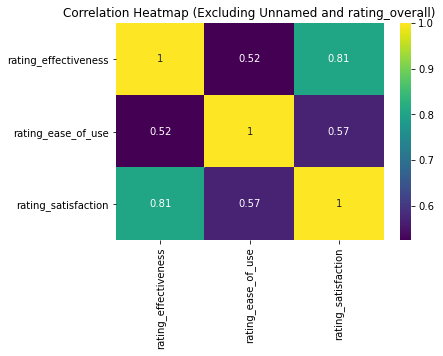

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
data = pd.read_csv('Data.csv', parse_dates=['date'], index_col='date')

# Select relevant columns
selected_columns = ['rating_effectiveness', 'rating_ease_of_use', 'rating_satisfaction']
data_selected = data[selected_columns]

# Calculate correlations
correlations = data_selected.corr()

# Create a heatmap
sns.heatmap(correlations, annot=True, cmap='viridis')
plt.title('Correlation Heatmap (Excluding Unnamed and rating_overall)')
plt.show()

Missing values summary:
Unnamed: 0              0
drug_name               0
age                     0
gender                  0
time_on_drug            0
reviewer_type           0
condition               0
rating_overall          0
rating_effectiveness    0
rating_ease_of_use      0
rating_satisfaction     0
text                    0
dtype: int64


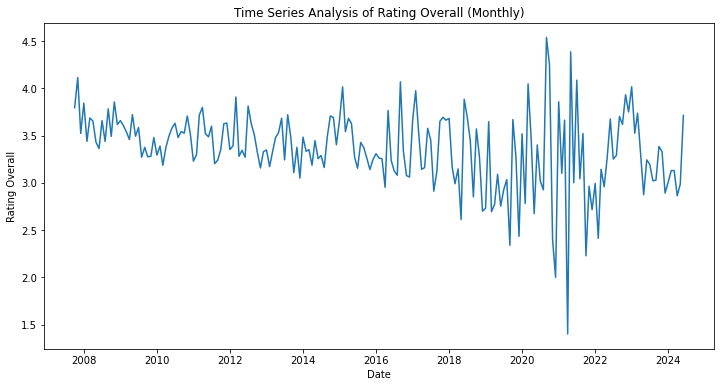

ADF Statistic: -36.613588193951294
p-value: 0.0
Critical Values: {'1%': -3.4308146226356766, '5%': -2.8617453421166705, '10%': -2.5668792988239937}


In [31]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data (replace 'Data.csv' with your actual path)
data = pd.read_csv('Data.csv', parse_dates=['date'], index_col='date')

# Ensure date format is valid (e.g., YYYY-MM-DD)

# Handle missing values (adjust method as needed)
data.fillna(method='ffill', inplace=True)  # Fill missing values with previous valid value

# Explore missing values
print("Missing values summary:")
print(data.isnull().sum())


data = data.sort_index(ascending=True)  # Sort by date if necessary

# Time Series Analysis (using rating_overall as an example)
# Basic time series plot (resampled to monthly)
resampled_data = data['rating_overall'].resample('M').mean()
plt.figure(figsize=(12, 6))
plt.plot(resampled_data)
plt.title('Time Series Analysis of Rating Overall (Monthly)')
plt.xlabel('Date')
plt.ylabel('Rating Overall')
plt.show()

# Check stationarity (ADF test)
result = sm.tsa.stattools.adfuller(data['rating_overall'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# If the data is not stationary, you might need to difference it or apply other transformations

# Example: ARIMA model (you might need to adjust the order)
# model = ARIMA(data['rating_overall'], order=(1, 1, 1))
# try:
#   results = model.fit()
#   print(results.summary())

#   # Forecasting (optional, using integer index for now)
#   forecast = results.forecast(steps=3)
#   print("Forecasted values (using integer index):", forecast)

# except Exception as e:
#   print("ARIMA model fitting failed:", e)


# # Correlation Analysis (excluding 'rating_overall' and potentially 'Unnamed: 0')
# selected_columns = ['rating_effectiveness', 'rating_ease_of_use', 'rating_satisfaction']  # Adjust as needed
# data_selected = data[selected_columns]

# correlations = data_selected.corr()

# # Create a heatmap
# sns.heatmap(correlations, annot=True, cmap='viridis')
# plt.title('Correlation Heatmap')
# plt.show()

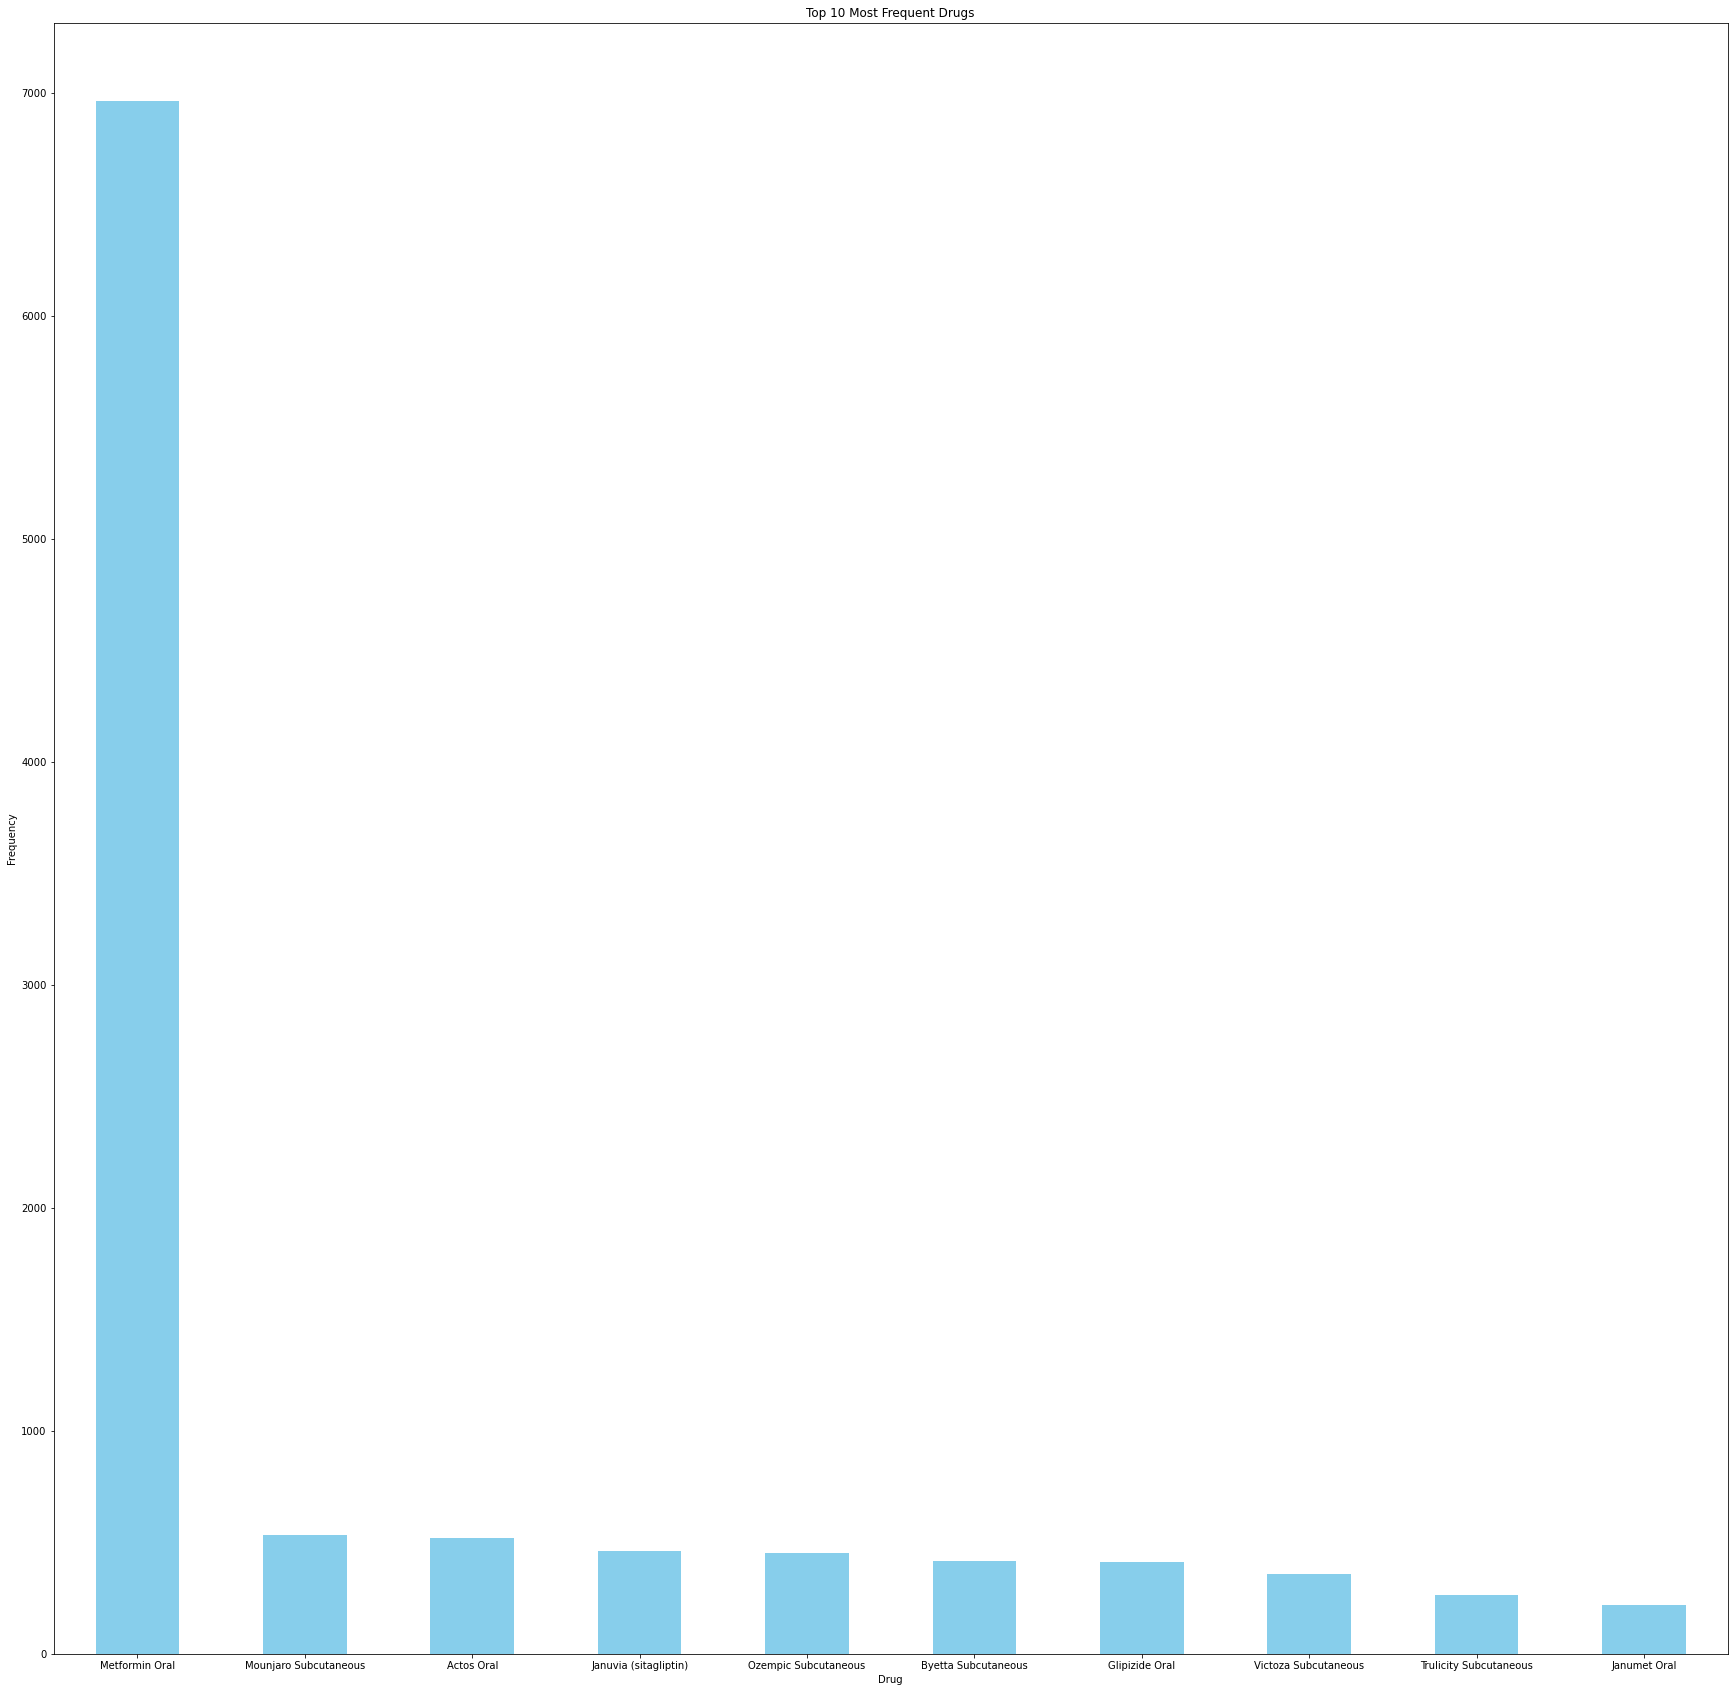

In [32]:
# Filter the top 10 most frequent brands and create a bar chart
import matplotlib.pyplot as plt
drug_counts = sentiment_data['drug_name'].value_counts().head(10)
plt.figure(figsize=(30, 30))
drug_counts.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Frequent Drugs')
plt.xlabel('Drug')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()


In [33]:
# # Filter the top 10 most frequent brands and create a bar chart
# import matplotlib.pyplot as plt
# drug_counts = sentiment_data['date'].value_counts().head(10)
# plt.figure(figsize=(30, 30))
# drug_counts.plot(kind='bar', color='skyblue')
# plt.title('Top 10 Most Frequent Dates')
# plt.xlabel('Date')
# plt.ylabel('Frequency') 
# plt.xticks(rotation=0)
# plt.show()

In [34]:
# # Filter for brand Ford and create a correlation matrix
# ford_df = df[df['Brand'] == 'Ford']
# ford_correlation = ford_df[['odometer', 'sellingprice']].corr()

# # Filter for brand Ford and create a correlation matrix
# import seaborn as sns

# ford_df = df[df['Brand'] == 'Ford']
# ford_correlation = ford_df[['odometer', 'sellingprice']].corr()

# # Create a correlation matrix plot for Ford using seaborn
# sns.set_theme()  # Set a theme for better aesthetics
# plt.figure(figsize=(8, 6))
# sns.heatmap(ford_correlation, annot=True, cmap='coolwarm')
# plt.title('Correlation Matrix (Ford)')
# plt.show()

# Filter for brand Ford and create a correlation matrix
# ozempic_df = df[drug_pres['drug_name'] == 'Ozempic Subcutaneous']
# ozempic_df.count()
# ozempic_df
# ford_correlation = ford_df[['odometer', 'sellingprice']].corr()

# # Filter for brand Ford and create a correlation matrix
# import seaborn as sns

# ford_df = df[df['Brand'] == 'Ford']
# ford_correlation = ford_df[['odometer', 'sellingprice']].corr()

# # Create a correlation matrix plot for Ford using seaborn
# sns.set_theme()  # Set a theme for better aesthetics
# plt.figure(figsize=(8, 6))
# sns.heatmap(ford_correlation, annot=True, cmap='coolwarm')
# plt.title('Correlation Matrix (Ford)')
# plt.show()



Existing frequency: None
         Unnamed: 0  rating_overall  rating_effectiveness  rating_ease_of_use  \
count    450.000000      450.000000            450.000000          450.000000   
mean   11698.500000        3.587778              3.586667            4.013333   
std      130.048068        1.290105              1.508048            1.234183   
min    11474.000000        1.000000              1.000000            1.000000   
25%    11586.250000        2.300000              2.000000            3.000000   
50%    11698.500000        4.000000              4.000000            4.000000   
75%    11810.750000        5.000000              5.000000            5.000000   
max    11923.000000        5.000000              5.000000            5.000000   

       rating_satisfaction  
count           450.000000  
mean              3.160000  
std               1.614577  
min               1.000000  
25%               1.000000  
50%               3.000000  
75%               5.000000  
max          

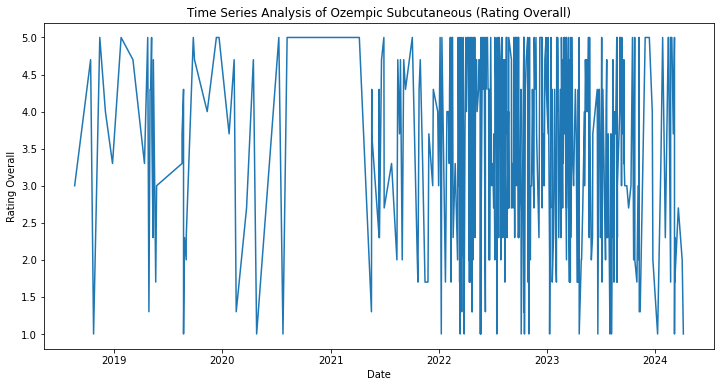

ADF Statistic: -14.301010481947028
p-value: 1.229081942654979e-26
Critical Values: {'1%': -3.4450311708077743, '5%': -2.8680131035505023, '10%': -2.570217924306441}


In [35]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Load your data (replace 'Data.csv' with your actual path)
data = pd.read_csv('Data.csv', parse_dates=['date'], index_col='date')

# Check the existing frequency
print("Existing frequency:", data.index.freq)

# Option 1: Continue with existing frequency (if suitable)
# Option 2: Resample to daily (if desired)
# daily_data = data.resample('D').mean()  # Uncomment and adjust if needed

# Filter data for "Ozempic Subcutaneous"
ozempic_data = data[data['drug_name'] == 'Ozempic Subcutaneous']

# Explore filtered data
print(ozempic_data.describe())

# Time Series Analysis for Ozempic Subcutaneous (using existing or resampled data)
plt.figure(figsize=(12, 6))
plt.plot(ozempic_data['rating_overall'])
plt.title('Time Series Analysis of Ozempic Subcutaneous (Rating Overall)')
plt.xlabel('Date')
plt.ylabel('Rating Overall')
plt.show()

# Check stationarity (ADF test)
result = sm.tsa.stattools.adfuller(ozempic_data['rating_overall'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# If the data is not stationary, you might need to difference it or apply other transformations

# # Example: ARIMA model (you might need to adjust the order)
# model = ARIMA(ozempic_data['rating_overall'], order=(1, 1, 1))
# try:
#   results = model.fit()
#   print(results.summary())

#   # Forecasting
#   forecast = results.forecast(steps=3)
#   print("Forecasted values (using integer index):", forecast)

# except Exception as e:
#   print("ARIMA model fitting failed:", e)

Existing frequency: None


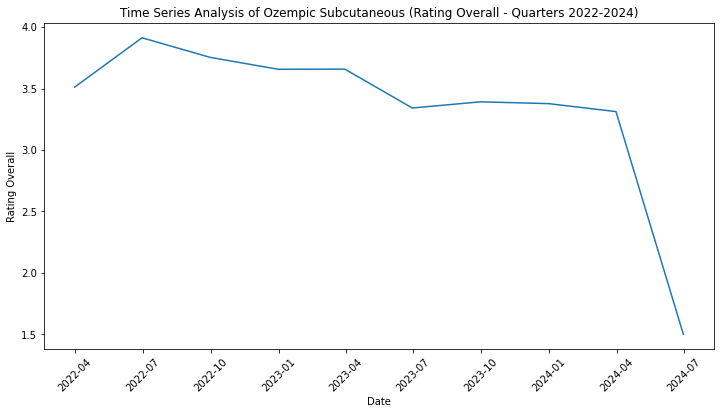

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data (replace 'Data.csv' with your actual path)
data = pd.read_csv('Data.csv', parse_dates=['date'], index_col='date')

# Check the existing frequency
print("Existing frequency:", data.index.freq)

# Resample to quarters between 2022 and 2024 (assuming quarterly data)
ozempic_data = data[data['drug_name'] == 'Ozempic Subcutaneous']
quarterly_data = ozempic_data.loc[(ozempic_data.index >= '2022-01-01') & (ozempic_data.index < '2024-10-27')]  # Adjust dates if needed
quarterly_data = quarterly_data.resample('Q').mean()  # Resample to quarters and take mean

# Time Series Analysis for Ozempic Subcutaneous (Quarters between 2022 and 2024)
plt.figure(figsize=(12, 6))
plt.plot(quarterly_data['rating_overall'])
plt.title('Time Series Analysis of Ozempic Subcutaneous (Rating Overall - Quarters 2022-2024)')
plt.xlabel('Date')
plt.ylabel('Rating Overall')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability with quarters

# Consider adding gridlines and other stylistic elements for clarity

plt.show()

# ... (rest of your code for stationarity analysis and ARIMA model fitting, if needed)

In [37]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from pandas.plotting import autocorrelation_plot
# import statsmodels.tsa.stattools as sm

# # Load data 
# data = pd.read_csv('Data.csv')

# # Check the data index type
# print("Data index dtype:", data.index.dtype)

# # Try converting date column to datetime and set as index (if applicable)
# if 'date' in data.columns:  # Check for a date column
#   try:
#     data['date'] = pd.to_datetime(data['date'])
#     data.set_index('date', inplace=True)
#     print("Converted date column to datetime index")
#   except:
#     print("Error converting date column to datetime")
#     # Handle the case where conversion fails (e.g., invalid date format)

# # Check if data has datetime index (optional)
# if not data.index.is_monotonic_increasing or not data.index.is_unique:
#     print("Data index might not be a datetime index")
#     # Consider converting to datetime index if needed (e.g., using pd.to_datetime)

# # Check the existing frequency (if applicable)
# try:
#   print("Existing frequency:", data.index.freq)
# except AttributeError:
#   print("Data index might not have a defined frequency")

# # Resample data to quarters (keeping all columns)
# try:
#   quarterly_data = data.resample('Q').agg('mean')
# except TypeError:
#   print("Resampling failed. Check data index")

# # Filter data for "Ozempic Subcutaneous" (if applicable)
# if 'drug_name' in data.columns:  # Check if column exists
#     ozempic_data = quarterly_data[quarterly_data['drug_name'] == 'Ozempic Subcutaneous']
# else:
#     print("Column 'drug_name' not found in data")
#     # Handle the case where the column is missing

# # Explore filtered data (if applicable)
# if 'drug_name' in data.columns:
#     print(ozempic_data.describe())

#     # ... rest of your time series analysis code for Ozempic Subcutaneous

#     # Time Series Analysis for Ozempic Subcutaneous
#     plt.figure(figsize=(12, 6))

#     # Plot with seasonal markers
#     plt.plot(ozempic_data['rating_overall'], marker='o', linestyle='-')
#     plt.title('Time Series Analysis of Ozempic Subcutaneous (Rating Overall - Quarterly)')
#     plt.xlabel('Date')
#     plt.ylabel('Rating Overall')

#     # Highlight years (optional)
#     for year in range(2021, 2025):
#         plt.axvline(x=pd.to_datetime(f"{year}-01-01"), color='gray', linestyle='--', alpha=0.5)

#     plt.show()

#     # Check autocorrelation for seasonality (optional)
#     autocorrelation_plot(ozempic_data['rating_overall'])
#     plt.show()

#     # Check stationarity (ADF test)
#     result = sm.tsa.stattools.adfuller(ozempic_data['rating_overall'])
#     print('ADF Statistic:', result[0])
#     print('p-value:', result[1])
#     print('Critical Values:', result[4])

In [38]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # Load your data (replace 'Data.csv' with your actual path)
# data = pd.read_csv('Data.csv', parse_dates=['date'], index_col='date')

# # Prepare data
# X = data[['rating_effectiveness', 'rating_ease_of_use', 'rating_satisfaction']]
# y = data['drug_name']

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Scale features (optional)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Create and train logistic regression model
# model = LogisticRegression(max_iter=1000)  # Increase max_iter if needed
# model.fit(X_train_scaled, y_train)

# # Make predictions
# predictions = model.predict(X_test_scaled)

# # Evaluate model performance
# accuracy = accuracy_score(y_test, predictions)
# classification_report = classification_report(y_test, predictions)
# confusion_matrix = confusion_matrix(y_test, predictions)

# print("Accuracy:", accuracy)
# print("Classification Report:\n", classification_report)
# print("Confusion Matrix:\n", confusion_matrix)

In [39]:
# # Encode categorical variable (if necessary)
# data['time_on_drug_encoded'] = data['time_on_drug'].factorize()[0]

# # Prepare data
# X = data[['rating_effectiveness', 'rating_ease_of_use', 'rating_satisfaction']]
# y = data['time_on_drug_encoded']

# # ... (rest of the code similar to the previous logistic regression)

In [40]:
# from sklearn.linear_model import LinearRegression

# # Prepare data
# X = data[['rating_effectiveness', 'rating_ease_of_use']]
# y = data['rating_satisfaction']

# # ... (rest of the code similar to the previous logistic regression)

In [41]:
# from textblob import TextBlob

# # Extract sentiment polarity
# data['sentiment'] = data['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# # Analyze sentiment distribution
# # ...

In [42]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [43]:
import seaborn as sns

In [44]:
pip


Usage:   
  C:\Users\ba7ar\anaconda3\python.exe -m pip <command> [options]

Commands:
  install                     Install packages.
  download                    Download packages.
  uninstall                   Uninstall packages.
  freeze                      Output installed packages in requirements format.
  list                        List installed packages.
  show                        Show information about installed packages.
  check                       Verify installed packages have compatible dependencies.
  config                      Manage local and global configuration.
  search                      Search PyPI for packages.
  cache                       Inspect and manage pip's wheel cache.
  wheel                       Build wheels from your requirements.
  hash                        Compute hashes of package archives.
  completion                  A helper command used for command completion.
  debug                       Show information useful for debugging.
 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ba7ar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Positive    6394
Negative    3875
Neutral     3815
Name: sentiment, dtype: int64


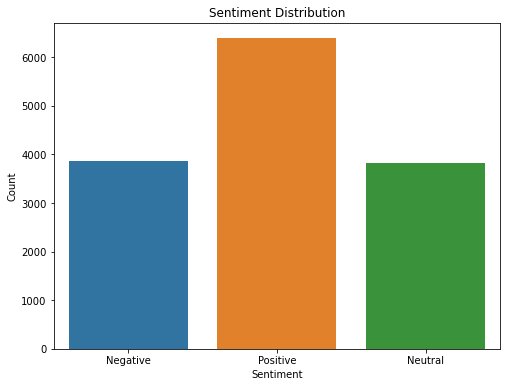

In [45]:
# import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import nltk
import seaborn as sns

# Download NLTK data
nltk.download('punkt')

# Load your data
data = pd.read_csv('Data.csv', parse_dates=['date'], index_col='date')

# Handle non-string values in "text" column (adjust as needed)
if pd.api.types.is_numeric_dtype(data['text']):
    # Convert numbers to strings (if applicable)
    data['text'] = data['text'].astype(str)
data['text'].fillna('', inplace=True)  # Impute missing values with empty strings (optional)

# Sentiment Analysis
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

data['sentiment'] = data['text'].apply(get_sentiment)

# Analyze sentiment distribution
sentiment_counts = data['sentiment'].value_counts()
print(sentiment_counts)

# Visualize sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=data)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ba7ar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Positive    263
Negative    160
Neutral      27
Name: sentiment, dtype: int64


<ipython-input-46-5766692b9fb1>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ozempic_data['sentiment'] = ozempic_data['text'].apply(get_sentiment)


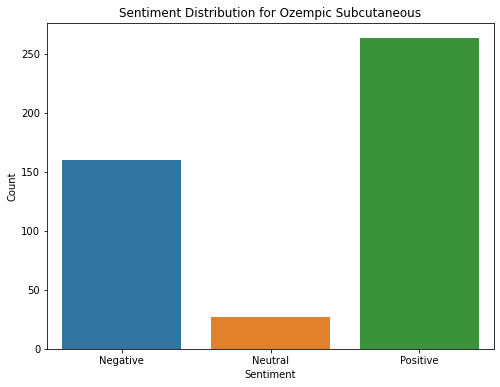

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import nltk
import seaborn as sns

# Download NLTK data (if not already downloaded)
nltk.download('punkt')

# Load your data
data = pd.read_csv('Data.csv', parse_dates=['date'], index_col='date')

# Handle non-string values in "text" column (adjust as needed)
if pd.api.types.is_numeric_dtype(data['text']):
  # Convert numbers to strings (if applicable)
  data['text'] = data['text'].astype(str)
data['text'].fillna('', inplace=True)  # Impute missing values with empty strings (optional)

# Filter data for Ozempic Subcutaneous (replace with your drug name)
ozempic_data = data[data['drug_name'] == 'Ozempic Subcutaneous']  # Adjust drug name

# Sentiment Analysis
def get_sentiment(text):
  analysis = TextBlob(text)
  if analysis.sentiment.polarity > 0:
    return 'Positive'
  elif analysis.sentiment.polarity == 0:
    return 'Neutral'
  else:
    return 'Negative'

ozempic_data['sentiment'] = ozempic_data['text'].apply(get_sentiment)

# Analyze sentiment distribution for Ozempic
sentiment_counts = ozempic_data['sentiment'].value_counts()
print(sentiment_counts)

# Visualize sentiment distribution for Ozempic
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=ozempic_data)
plt.title('Sentiment Distribution for Ozempic Subcutaneous')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

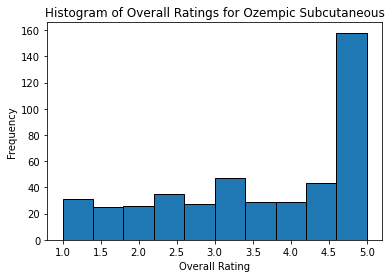

In [47]:
import matplotlib.pyplot as plt

# ... (rest of your code)

# Create a histogram for overall rating
plt.hist(ozempic_data['rating_overall'], bins=10, edgecolor='black')
plt.title('Histogram of Overall Ratings for Ozempic Subcutaneous')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.show()

object


C:\Users\ba7ar\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
<ipython-input-48-ccd9491c7746>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ozempic_data['sentiment_score'] = ozempic_data['text'].apply(get_sentiment)
No handles with labels found to put in legend.


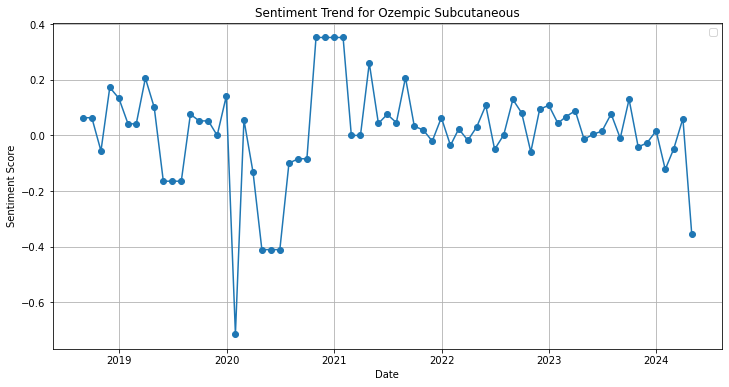

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import seaborn as sns

# Load your data
data = pd.read_csv('Data.csv', parse_dates=['date'], index_col='date')

# Filter data for Ozempic Subcutaneous
ozempic_data = data[data['drug_name'] == 'Ozempic Subcutaneous']

# Check data types (optional)
print(ozempic_data['text'].dtypes)

# Handle non-string values (adjust as needed)
if not pd.api.types.is_numeric_dtype(ozempic_data['text']):
  # No need to convert
  pass
else:
  # Convert numbers to strings (assuming numerical ratings)
  ozempic_data['text'] = ozempic_data['text'].astype(str)

# Impute missing values
ozempic_data['text'].fillna('', inplace=True)

# ... rest of your code for sentiment analysis and plotting ...

# Sentiment Analysis
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

ozempic_data['sentiment_score'] = ozempic_data['text'].apply(get_sentiment)

# ... (rest of your code)

# Resample data to monthly frequency (adjust as needed)
monthly_data = ozempic_data.resample('M').agg({'sentiment_score': 'mean'})

# Fill missing values (optional)
monthly_data.fillna(method='ffill', inplace=True)

# Plot the sentiment trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_data.index, monthly_data['sentiment_score'], marker='o', linestyle='-')
plt.title('Sentiment Trend for Ozempic Subcutaneous')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.grid(True)
plt.legend()
plt.show()

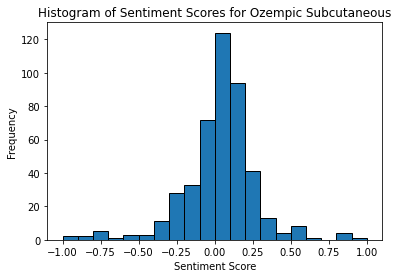

In [49]:
import matplotlib.pyplot as plt

# ... (rest of your code)

# Create a histogram
plt.hist(ozempic_data['sentiment_score'], bins=20, edgecolor='black')
plt.title('Histogram of Sentiment Scores for Ozempic Subcutaneous')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

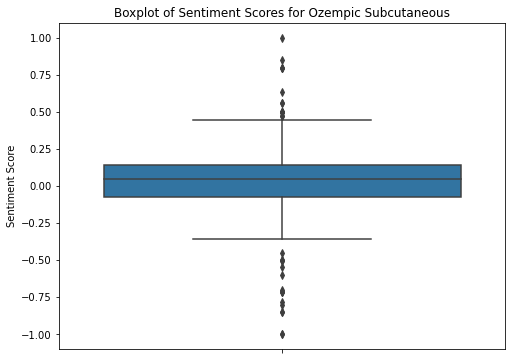

In [50]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=ozempic_data['sentiment_score'])
plt.title('Boxplot of Sentiment Scores for Ozempic Subcutaneous')
plt.ylabel('Sentiment Score')
plt.show()

In [51]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # ... (your data loading and filtering code)

# # Create a boxplot
# plt.figure(figsize=(8, 6))
# sns.boxplot(y=ozempic_data['rating_overall'])
# plt.title('Boxplot of Overall Rating for Ozempic Subcutaneous')
# plt.ylabel('Overall Rating')
# plt.show()

In [52]:
ozempic_data.head()

,Unnamed: 0,drug_name,age,gender,time_on_drug,reviewer_type,condition,rating_overall,rating_effectiveness,rating_ease_of_use,rating_satisfaction,text,sentiment_score
date,,,,,,,,,,,,,
2024-04-07,11474,Ozempic Subcutaneous,55-64,Female,less than 1 month,Patient,Weight Loss Management for an Obese Person,1.0,1,1,1,"I took the shot last Monday, threw up for 3 da...",-0.500000
2024-04-03,11475,Ozempic Subcutaneous,NaN,Female,1 to 6 months,Patient,Type 2 Diabetes Mellitus,2.0,4,1,1,It brought my A1c to6.8 all labs back to norma...,-0.209048
2024-03-21,11476,Ozempic Subcutaneous,65-74,Male,6 months to less than 1 year,Patient,Type 2 Diabetes Mellitus,2.7,3,4,1,Took for 8 months and now just diagnosed with ...,0.000000
2024-03-09,11477,Ozempic Subcutaneous,55-64,Female,less than 1 month,Patient,Other,1.7,1,3,1,I felt weak after the first .25 injection and ...,-0.038219
2024-03-09,11478,Ozempic Subcutaneous,55-64,Female,1 to 6 months,Patient,Other,2.3,2,4,1,OMG.....after the injections the first few wee...,0.040799


In [53]:
shortage_data.head()

,ARTG ID,ARTG name,Active ingredients,Dosage form,Quantity of active ingredients,Sponsor,Phone,Shortage status,Supply impact start date,Supply impact end date,Deletion from market,Shortage impact rating,Availability,Reason,Management action,Last updated
0,10013,TECHNESCAN MAG3 Kit for preparation of Technet...,betiatide,"Injection, powder for",1 mg,Landauer Radiopharmaceuticals Pty Ltd,02 8651 4000,Current,30/04/2024,31/01/2025,NaN,Medium,Unavailable,Manufacturing,Sponsor is working to expedite the next shipment.,7/5/2024
1,10047,CYMEVENE ganciclovir 500mg (as sodium) powder ...,ganciclovir sodium,"Injection, powder for",543 mg,Pharmaco Australia Ltd,1800201564,Resolved,30/05/2024,4/7/2024,NaN,Critical,Available,Manufacturing,NaN,8/7/2024
2,100517,Q-VAX Q FEVER VACCINE 0.5mL injection syringe,Coxiella burnetii,Injection,50 microgram/mL,Seqirus Pty Ltd,1800642865,Current,31/05/2024,31/01/2025,NaN,Critical,Limited Availability,Manufacturing,The sponsor is closely controlling the supply.,9/8/2024
3,100518,Q-VAX SKIN TEST (Inactivated C. burnetii for P...,Coxiella burnetii,Injection,5 microgram/mL,Seqirus Pty Ltd,1800642865,Current,31/05/2024,31/01/2025,NaN,Medium,Limited Availability,Manufacturing,The sponsor is closely controlling the supply.,13/08/2024
4,10052,NORIDAY 28 DAY norethisterone 350 microgram ta...,norethisterone,"Tablet, uncoated",350 microgram,Pfizer Australia Pty Ltd,1800 675 229,Current,11/9/2024,31/12/2024,NaN,Medium,Unavailable,Manufacturing,The sponsor is closely controlling the supply.,17/09/2024


In [54]:
shortage_data.columns


Index(['ARTG ID', 'ARTG name', 'Active ingredients', 'Dosage form',
       'Quantity of active ingredients', 'Sponsor', 'Phone', 'Shortage status',
       'Supply impact start date', 'Supply impact end date',
       'Deletion from market', 'Shortage impact rating', 'Availability',
       'Reason', 'Management action', 'Last updated'],
      dtype='object')

In [55]:
ozempic_data.columns

Index(['Unnamed: 0', 'drug_name', 'age', 'gender', 'time_on_drug',
       'reviewer_type', 'condition', 'rating_overall', 'rating_effectiveness',
       'rating_ease_of_use', 'rating_satisfaction', 'text', 'sentiment_score'],
      dtype='object')

In [56]:
sentiment_data.columns

Index(['Unnamed: 0', 'drug_name', 'date', 'age', 'gender', 'time_on_drug',
       'reviewer_type', 'condition', 'rating_overall', 'rating_effectiveness',
       'rating_ease_of_use', 'rating_satisfaction', 'text'],
      dtype='object')

In [57]:
# type(ozempic_data['date'].iloc[0])

In [58]:
import pandas as pd

# Assuming you have 'sentiment_data' and 'shortage_data' DataFrames

# Filter sentiment data for Ozempic Subcutaneous
ozempic_data = sentiment_data[sentiment_data['drug_name'] == 'Ozempic Subcutaneous']

# Ensure date columns are in datetime format
ozempic_data['date'] = pd.to_datetime(ozempic_data['date'])
shortage_data['Supply impact start date'] = pd.to_datetime(shortage_data['Supply impact start date'])
shortage_data['Supply impact end date'] = pd.to_datetime(shortage_data['Supply impact end date'])

# Merge DataFrames based on date ranges
merged_data = ozempic_data.copy()

for index, row in shortage_data.iterrows():
    start_date = row['Supply impact start date']
    end_date = row['Supply impact end date']
    merged_data.loc[(merged_data['date'] >= start_date) & (merged_data['date'] <= end_date), 'shortage_period'] = True

# Calculate average sentiment during shortage and non-shortage periods
average_sentiment_during_shortage = merged_data[merged_data['shortage_period'] == True]['rating_overall'].mean()
average_sentiment_outside_shortage = merged_data[merged_data['shortage_period'] == False]['rating_overall'].mean()

print("Average sentiment during shortage:", average_sentiment_during_shortage)
print("Average sentiment outside shortage:", average_sentiment_outside_shortage)

# ... (rest of your analysis and visualization)

<ipython-input-58-b85f1affd1c5>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ozempic_data['date'] = pd.to_datetime(ozempic_data['date'])


Average sentiment during shortage: 3.587777777777778
Average sentiment outside shortage: nan


In [59]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # ... (rest of your code)

# # Create a time series plot, focusing on 2019-2024
# plt.figure(figsize=(12, 6))
# plt.plot(monthly_data.index, monthly_data['rating_overall'], label='Overall Rating')

# # Highlight shortage periods
# for index, row in shortage_data.iterrows():
#     start_date = row['Supply impact start date']
#     end_date = row['Supply impact end date']

#     # Skip rows with NaT values to avoid plotting errors
#     if not pd.isna(start_date) and not pd.isna(end_date):
#         plt.axvspan(start_date, end_date, color='red', alpha=0.2, label='Shortage Period' if index == 0 else '')

# # Set x-axis limits to 2019-2024
# plt.xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2024-12-31'))

# plt.title('Average Rating Over Time with Shortage Periods (2019-2024)')
# plt.xlabel('Date')
# plt.ylabel('Average Rating')
# plt.legend()
# plt.grid(True)
# plt.show()

In [62]:
monthly_data.head()

,sentiment_score
date,
2018-08-31,0.063580
2018-09-30,0.063580
2018-10-31,-0.055729
2018-11-30,0.172727
2018-12-31,0.133333


In [63]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # ... (rest of your code)

# # Create a time series plot, focusing on 2019-2024
# plt.figure(figsize=(12, 6))
# plt.plot(monthly_data.index, monthly_data['rating_overall'], label='Overall Rating')

# # Highlight shortage periods with a lighter red and transparency
# for index, row in shortage_data.iterrows():
#     start_date = row['Supply impact start date']
#     end_date = row['Supply impact end date']

#     if not pd.isna(start_date) and not pd.isna(end_date):
#         plt.axvspan(start_date, end_date, color='lightcoral', alpha=0.5, label='Shortage Period' if index == 0 else '')

# plt.title('Average Rating Over Time with Shortage Periods (2019-2024)')
# plt.xlabel('Date')
# plt.ylabel('Average Rating')
# plt.legend()
# plt.grid(True)
# plt.show()

In [64]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # ... (rest of your code)

# # Set the minimum and maximum dates for the plot
# min_date = merged_data['date'].min()
# max_date = merged_data['date'].max()

# # Create a time series plot
# plt.figure(figsize=(12, 6))
# plt.plot(monthly_data.index, monthly_data['rating_overall'], label='Overall Rating')

# # Highlight shortage periods
# for index, row in shortage_data.iterrows():
#     start_date = row['Supply impact start date']
#     end_date = row['Supply impact end date']

#     if not pd.isna(start_date) and not pd.isna(end_date):
#         plt.axvspan(start_date, end_date, color='lightcoral', alpha=0.2, label='Shortage Period' if index == 0 else '')

# plt.title('Average Rating Over Time with Shortage Periods')
# plt.xlabel('Date')
# plt.ylabel('Average Rating')
# plt.legend()
# plt.grid(True)
# plt.xlim(min_date, max_date)  # Set x-axis limits based on data range
# plt.show()

In [65]:
import pandas as pd

# Assuming you have 'sentiment_data' and 'shortage_data' DataFrames

# Filter sentiment data for Ozempic Subcutaneous
ozempic_data = sentiment_data[sentiment_data['drug_name'] == 'Ozempic Subcutaneous']

# Filter shortage data for Ozempic (Assuming 'ARTG name' contains 'Ozempic')
ozempic_shortages = shortage_data[shortage_data['ARTG name'].str.contains('Ozempic')]

# Ensure consistent date format - This is crucial!
ozempic_data['date'] = pd.to_datetime(ozempic_data['date'])
ozempic_shortages['date'] = pd.to_datetime(ozempic_shortages['Supply impact start date'])  # Potential issue
ozempic_shortages['Supply impact end date'] = pd.to_datetime(ozempic_shortages['Supply impact end date'])

# Merge DataFrames based on date ranges (assuming 'date' in both)
merged_data = ozempic_data.merge(ozempic_shortages, on='date', how='left')

# Create a new column to indicate shortage periods
merged_data['shortage_period'] = False
for index, row in ozempic_shortages.iterrows():
    start_date = row['Supply impact start date']
    end_date = row['Supply impact end date']
    merged_data.loc[(merged_data['date'] >= start_date) & (merged_data['date'] <= end_date), 'shortage_period'] = True

# Calculate average sentiment during shortage and non-shortage periods
average_sentiment_during_shortage = merged_data[merged_data['shortage_period'] == True]['rating_overall'].mean()
average_sentiment_outside_shortage = merged_data[merged_data['shortage_period'] == False]['rating_overall'].mean()

print("Average sentiment during shortage:", average_sentiment_during_shortage)
print("Average sentiment outside shortage:", average_sentiment_outside_shortage)

# ... (rest of your analysis and visualization)

Average sentiment during shortage: nan
Average sentiment outside shortage: 3.587777777777778


<ipython-input-65-75f75aca55d2>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ozempic_data['date'] = pd.to_datetime(ozempic_data['date'])


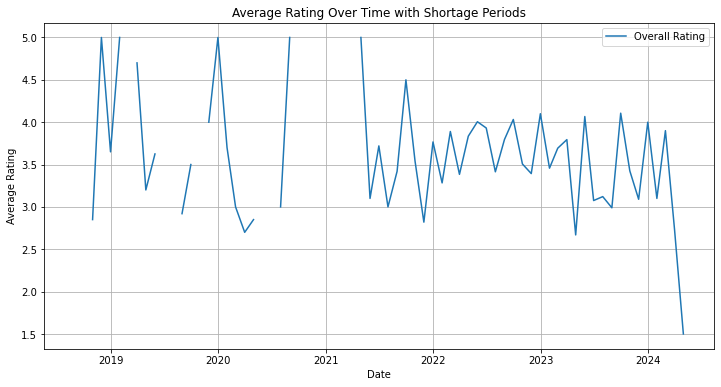

In [66]:
import matplotlib.pyplot as plt

# ... (rest of your code)

# Group the data by month and calculate the average rating
monthly_data = merged_data.groupby(pd.Grouper(key='date', freq='M')).mean()

# Plot the average rating over time
plt.figure(figsize=(12, 6))
plt.plot(monthly_data.index, monthly_data['rating_overall'], label='Overall Rating')

# Highlight shortage periods
for index, row in ozempic_shortages.iterrows():
    start_date = row['Supply impact start date']
    end_date = row['Supply impact end date']
    plt.axvspan(start_date, end_date, color='red', alpha=0.2, label='Shortage Period' if index == 0 else '')

plt.title('Average Rating Over Time with Shortage Periods')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.legend()
plt.grid(True)
plt.show()

In [67]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # ... (rest of your code)

# # Group data by month and calculate average rating
# monthly_data = merged_data.groupby(pd.Grouper(key='date', freq='M')).mean()

# # Create a time series plot
# plt.figure(figsize=(12, 6))
# plt.plot(monthly_data.index, monthly_data['rating_overall'], label='Overall Rating')

# # Highlight shortage periods
# for index, row in ozempic_shortages.iterrows():
#     start_date = row['Supply impact start date']
#     end_date = row['Supply impact end date']
#     plt.axvspan(start_date, end_date, color='lightcoral', alpha=0.2, label='Shortage Period' if index == 0 else '')

# plt.title('Average Rating Over Time with Shortage Periods')
# plt.xlabel('Date')
# plt.ylabel('Average Rating')
# plt.legend()
# plt.grid(True)
# plt.show()

In [68]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # ... (rest of your code)

# # Group the data by month and calculate average rating for each period
# monthly_data_shortage = merged_data[merged_data['shortage_period'] == True].groupby(pd.Grouper(key='date', freq='M')).mean()
# monthly_data_non_shortage = merged_data[merged_data['shortage_period'] == False].groupby(pd.Grouper(key='date', freq='M')).mean()

# # Create a time series plot
# plt.figure(figsize=(12, 6))
# plt.plot(monthly_data_shortage.index, monthly_data_shortage['rating_overall'], label='Shortage Period')
# plt.plot(monthly_data_non_shortage.index, monthly_data_non_shortage['rating_overall'], label='Non-Shortage Period')

# plt.title('Average Rating Over Time with Shortage Periods')
# plt.xlabel('Date')
# plt.ylabel('Average Rating')
# plt.legend()
# plt.grid(True)
# plt.show()

In [69]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Assuming 'sentiment_data' and 'shortage_data' are loaded

# # Filter sentiment data for Ozempic Subcutaneous
# ozempic_data = sentiment_data[sentiment_data['drug_name'] == 'Ozempic Subcutaneous']

# # Convert date columns to datetime format
# ozempic_data['date'] = pd.to_datetime(ozempic_data['date'])
# shortage_data['Supply impact start date'] = pd.to_datetime(shortage_data['Supply impact start date'])
# shortage_data['Supply impact end date'] = pd.to_datetime(shortage_data['Supply impact end date'])

# # Filter shortage data based on date range (adjust as needed)
# start_date = pd.to_datetime('2023-01-01')  # Adjust start date as needed
# end_date = pd.to_datetime('2024-01-01')  # Adjust end date as needed
# shortage_data = shortage_data[(shortage_data['Supply impact start date'] >= start_date) & 
#                                (shortage_data['Supply impact end date'] <= end_date)]

# # Merge DataFrames based on date ranges
# merged_data = ozempic_data.merge(shortage_data, how='left', on='date')

# # Create a new column to indicate shortage periods
# merged_data['shortage_period'] = False
# for index, row in shortage_data.iterrows():
#     start_date = row['Supply impact start date']
#     end_date = row['Supply impact end date']
#     merged_data.loc[(merged_data['date'] >= start_date) & (merged_data['date'] <= end_date), 'shortage_period'] = True

# # Group data by month and shortage period
# grouped_data = merged_data.groupby([pd.Grouper(key='date', freq='M'), 'shortage_period']).mean()

# # Access data for both periods
# shortage_ratings = grouped_data['rating_overall'][True]
# non_shortage_ratings = grouped_data['rating_overall'][False]

# # Plot the average rating over time for both periods
# plt.figure(figsize=(12, 6))
# plt.plot(shortage_ratings.index.levels[0], shortage_ratings, label='Shortage Period')
# plt.plot(non_shortage_ratings.index.levels[0], non_shortage_ratings, label='Non-Shortage Period')

# plt.title('Average Rating Over Time with Shortage Periods')
# plt.xlabel('Date')
# plt.ylabel('Average Rating')
# plt.legend()
# plt.grid(True)
# plt.show()

In [70]:
print(ozempic_data.columns)

Index(['Unnamed: 0', 'drug_name', 'date', 'age', 'gender', 'time_on_drug',
       'reviewer_type', 'condition', 'rating_overall', 'rating_effectiveness',
       'rating_ease_of_use', 'rating_satisfaction', 'text'],
      dtype='object')


In [71]:
print(shortage_data.columns)

Index(['ARTG ID', 'ARTG name', 'Active ingredients', 'Dosage form',
       'Quantity of active ingredients', 'Sponsor', 'Phone', 'Shortage status',
       'Supply impact start date', 'Supply impact end date',
       'Deletion from market', 'Shortage impact rating', 'Availability',
       'Reason', 'Management action', 'Last updated'],
      dtype='object')


In [72]:
print(ozempic_data['date'].dtype)

datetime64[ns]


In [73]:
print(shortage_data['Supply impact start date'].dtype)

datetime64[ns]


In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# ... (rest of your code)

# Merge DataFrames based on the date range
merged_data = ozempic_data.merge(shortage_data, how='left', left_on='date', right_on='Supply impact start date')

# ... (rest of your code)
# Create a new column to indicate shortage periods
merged_data['shortage_period'] = False
for index, row in shortage_data.iterrows():
    start_date = row['Supply impact start date']
    end_date = row['Supply impact end date']
    merged_data.loc[(merged_data['date'] >= start_date) & (merged_data['date'] <= end_date), 'shortage_period'] = True
    


In [77]:
merged_data.head()

,Unnamed: 0,drug_name,date,age,gender,time_on_drug,reviewer_type,condition,rating_overall,rating_effectiveness,...,Shortage status,Supply impact start date,Supply impact end date,Deletion from market,Shortage impact rating,Availability,Reason,Management action,Last updated,shortage_period
0,11474,Ozempic Subcutaneous,2024-04-07,55-64,Female,less than 1 month,Patient,Weight Loss Management for an Obese Person,1.0,1,...,Resolved,2024-04-07,2024-07-22,NaN,Low,Available,Manufacturing,NaN,6/8/2024,True
1,11474,Ozempic Subcutaneous,2024-04-07,55-64,Female,less than 1 month,Patient,Weight Loss Management for an Obese Person,1.0,1,...,Resolved,2024-04-07,2024-04-07,NaN,Low,Available,Unexpected increase in consumer demand,NaN,4/7/2024,True
2,11474,Ozempic Subcutaneous,2024-04-07,55-64,Female,less than 1 month,Patient,Weight Loss Management for an Obese Person,1.0,1,...,Resolved,2024-04-07,2024-08-23,NaN,Low,Available,Manufacturing,NaN,27/08/2024,True
3,11475,Ozempic Subcutaneous,2024-04-03,NaN,Female,1 to 6 months,Patient,Type 2 Diabetes Mellitus,2.0,4,...,Current,2024-04-03,2025-03-21,NaN,Low,Limited Availability,Manufacturing,An alternative generic product is available.,10/7/2024,True
4,11475,Ozempic Subcutaneous,2024-04-03,NaN,Female,1 to 6 months,Patient,Type 2 Diabetes Mellitus,2.0,4,...,Resolved,2024-04-03,2024-08-19,NaN,Low,Available,Manufacturing,NaN,29/08/2024,True


In [78]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # Prepare data (same as before)

# # Split data into training and testing sets

# # Fit the LDA model
# model = LDA()
# model.fit(X_train, y_train)

# # Make predictions
# predictions = model.predict(X_test)

# # Evaluate model performance
# accuracy = accuracy_score(y_test, predictions)
# print("Accuracy:", accuracy)

# print("Classification Report:")
# print(classification_report(y_test, predictions))

# confusion_matrix = confusion_matrix(y_test, predictions)
# print("Confusion Matrix:\n", confusion_matrix)

In [79]:
# from sklearn.model_selection import train_test_split
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # Filter data for top 5 most frequent drug categories (adjust as needed)
# top_drugs = data['drug_name'].value_counts().head(5).index
# filtered_data = data[data['drug_name'].isin(top_drugs)]

# # Prepare data
# X = filtered_data[['rating_effectiveness', 'rating_ease_of_use', 'rating_satisfaction']]
# y = filtered_data['drug_name']

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Fit the LDA model
# model = LDA()
# model.fit(X_train, y_train)

# # Make predictions
# predictions = model.predict(X_test)

# # Evaluate model performance
# accuracy = accuracy_score(y_test, predictions)
# print("Accuracy:", accuracy)

# print("Classification Report:")
# print(classification_report(y_test, predictions))

# confusion_matrix = confusion_matrix(y_test, predictions)
# print("Confusion Matrix:\n", confusion_matrix)

In [80]:
import pandas as pd

# Assuming you have loaded the dataset into a DataFrame named 'shortaged_data'

# Get basic information about the dataset
print(shortage_data.info())

# Check for missing values
print(shortage_data.isnull().sum())

# Explore categorical variables
categorical_cols = shortage_data.select_dtypes(include=['object']).columns

# Display unique values and their counts for each categorical variable
for col in categorical_cols:
    print(f"\n{col}:")
    print(shortage_data[col].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ARTG ID                         985 non-null    int64         
 1   ARTG name                       985 non-null    object        
 2   Active ingredients              985 non-null    object        
 3   Dosage form                     985 non-null    object        
 4   Quantity of active ingredients  985 non-null    object        
 5   Sponsor                         985 non-null    object        
 6   Phone                           985 non-null    object        
 7   Shortage status                 985 non-null    object        
 8   Supply impact start date        717 non-null    datetime64[ns]
 9   Supply impact end date          717 non-null    datetime64[ns]
 10  Deletion from market            268 non-null    object        
 11  Shorta